# Notebook 07 — Hallmark Pathway Enrichment

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import anndata as ad
import scanpy as sc
import gseapy as gp
from gseapy import Msigdb, barplot

In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=150, facecolor='white')
plt.rcParams['axes.grid'] = False

outdir = '../figures/'
os.makedirs(outdir, exist_ok=True)

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==2.0.2 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.6.0


## MSigDB gene sets

In [3]:
msig = Msigdb()
gmt = msig.get_gmt(category='mh.all', dbver='2023.1.Mm')
gmt2 = msig.get_gmt(category='m2.cp', dbver='2023.1.Mm')

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/msigdb.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  d = pd.read_html(resp.text)[0]
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/msigdb.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  d = pd.read_html(resp.text)[0]


## Load

In [4]:
adata = ad.read_h5ad('../data/processed/Gladstein Neighborhoods plus segmented tumors.h5ad')
adata

AnnData object with n_obs × n_vars = 1276555 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'batch', 'Genotype', 'n_genes_by_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'leiden', 'Cell Type', 'X_centroid', 'Y_centroid', 'neigh30_kmeans30', 'Cellular Neighborhood', 'tumor', 'tumor_barcode', 'tumor_binary', 'tcell_activation_score', 'ifng_response_score', 'ifna_response_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Cell Type_colors', 'Cellular Neighborhood_colors', 'hvg', 'l

## Differential expression — malignant cells by genotype

In [5]:
malignant_types = ['Malignant 1', 'Malignant 2 (AT2-like)', 'Malignant 3']
malig = adata[adata.obs['Cell Type'].isin(malignant_types)].copy()
malig

AnnData object with n_obs × n_vars = 359397 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'batch', 'Genotype', 'n_genes_by_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'leiden', 'Cell Type', 'X_centroid', 'Y_centroid', 'neigh30_kmeans30', 'Cellular Neighborhood', 'tumor', 'tumor_barcode', 'tumor_binary', 'tcell_activation_score', 'ifng_response_score', 'ifna_response_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Cell Type_colors', 'Cellular Neighborhood_colors', 'hvg', 'le

ranking genes


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


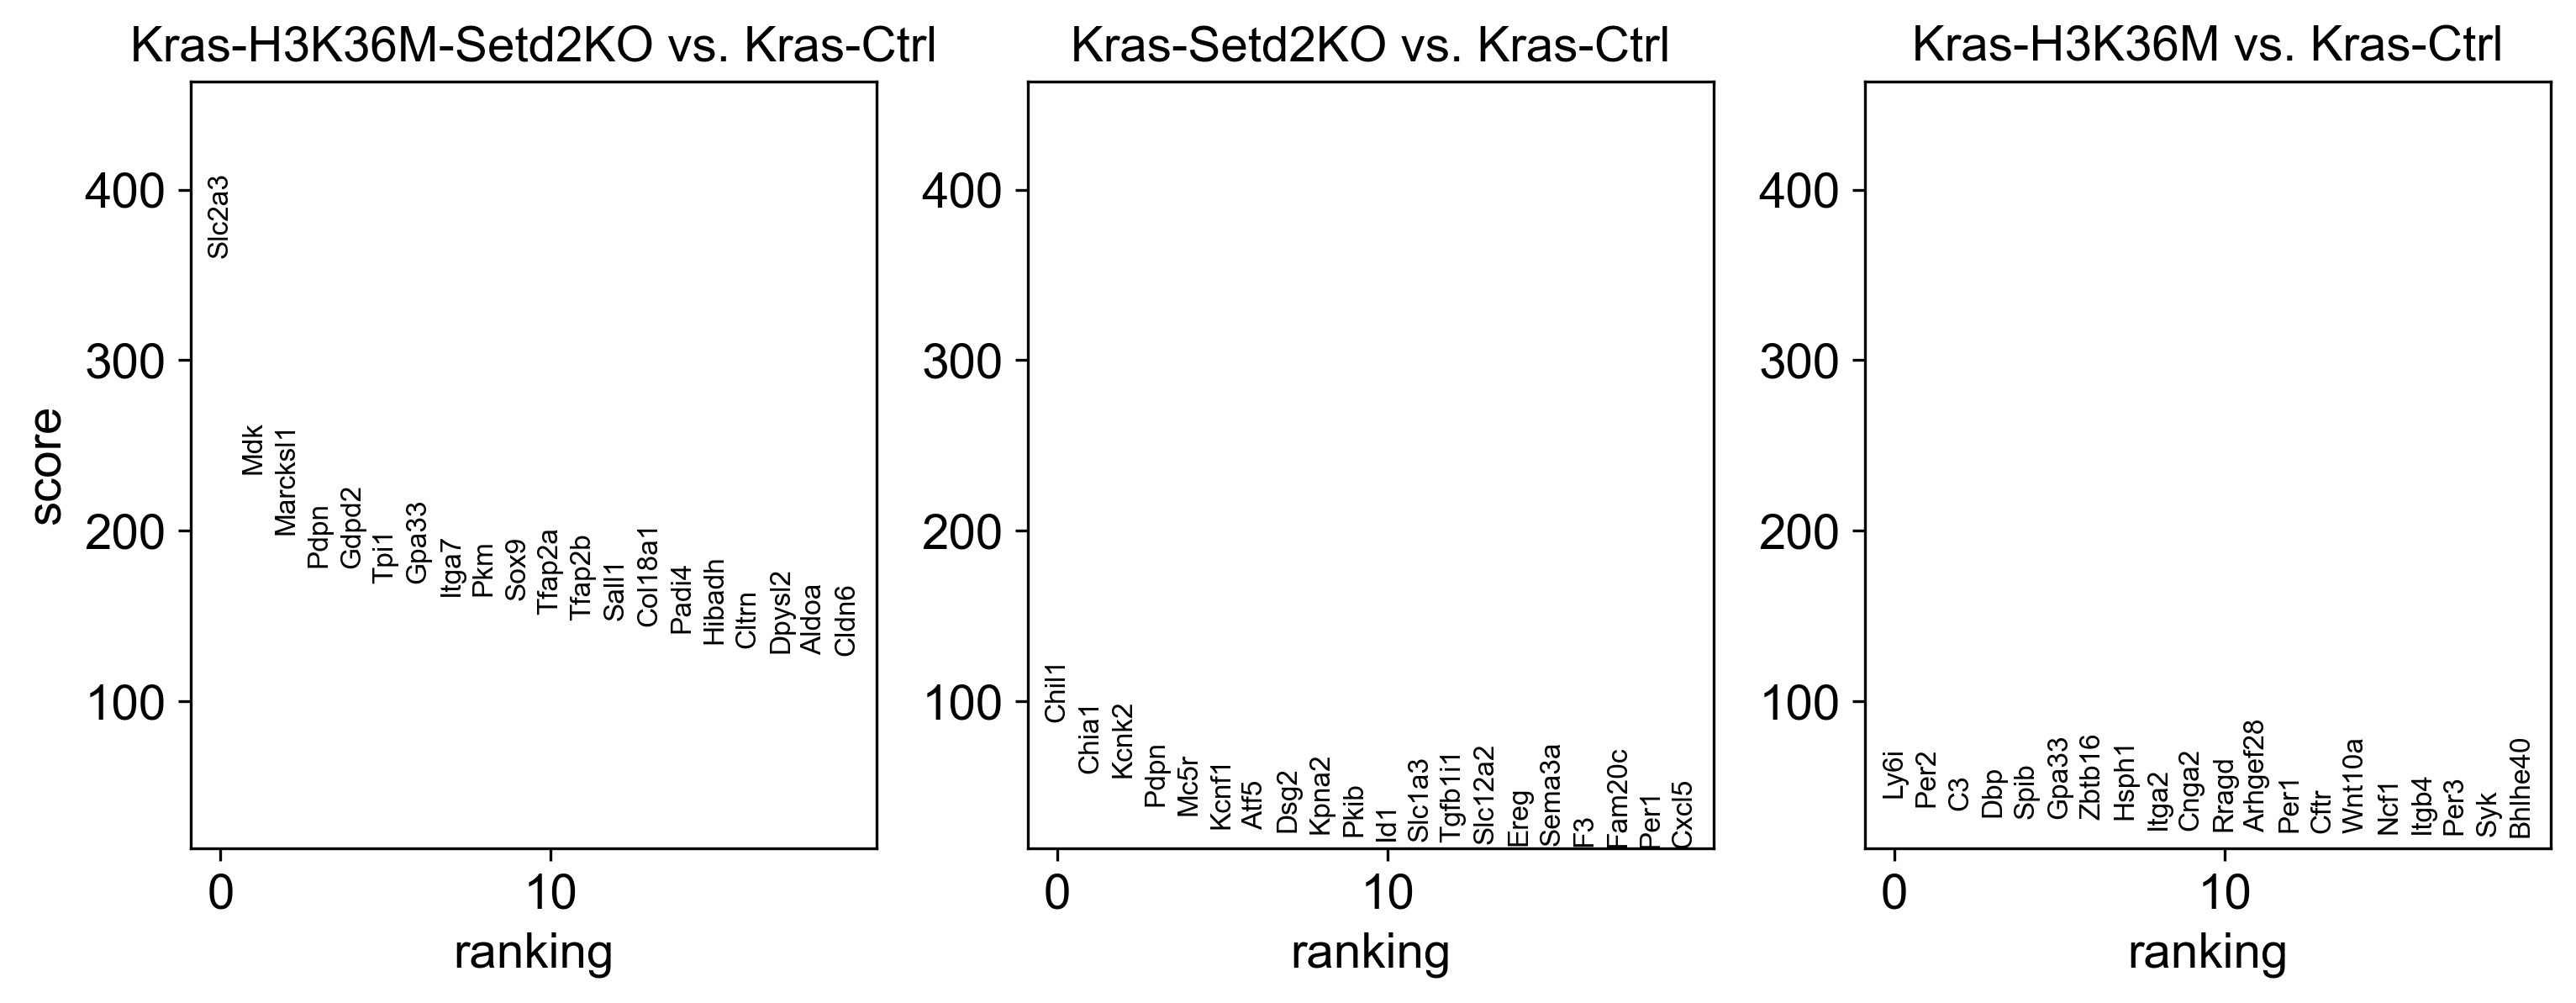

In [6]:
sc.tl.rank_genes_groups(
    malig,
    groupby='Genotype',
    reference='Kras-Ctrl',
)
sc.pl.rank_genes_groups(malig)

In [7]:
result = malig.uns['rank_genes_groups']
groups = result['names'].dtype.names

degs = pd.DataFrame({
    f'{group}_{key}': result[key][group]
    for group in groups
    for key in ['names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges']
})
degs.head()

,Kras-H3K36M-Setd2KO_names,Kras-H3K36M-Setd2KO_scores,Kras-H3K36M-Setd2KO_pvals,Kras-H3K36M-Setd2KO_pvals_adj,Kras-H3K36M-Setd2KO_logfoldchanges,Kras-Setd2KO_names,Kras-Setd2KO_scores,Kras-Setd2KO_pvals,Kras-Setd2KO_pvals_adj,Kras-Setd2KO_logfoldchanges,Kras-H3K36M_names,Kras-H3K36M_scores,Kras-H3K36M_pvals,Kras-H3K36M_pvals_adj,Kras-H3K36M_logfoldchanges
0,Slc2a3,359.788361,0.0,0.0,6.688817,Chil1,88.165749,0.000000e+00,0.000000e+00,0.749579,Ly6i,43.787907,0.000000e+00,0.000000e+00,2.047265
1,Mdk,233.114349,0.0,0.0,4.404160,Chia1,57.758896,0.000000e+00,0.000000e+00,0.739638,Per2,37.964157,1.830406e-303,1.041251e-301,1.837697
2,Marcksl1,197.635376,0.0,0.0,2.527508,Kcnk2,55.611637,0.000000e+00,0.000000e+00,1.633210,C3,36.111240,2.983033e-276,1.539491e-274,0.918097
3,Pdpn,178.475922,0.0,0.0,3.154152,Pdpn,38.594883,0.000000e+00,0.000000e+00,1.672219,Dbp,31.995317,1.901037e-219,7.434837e-218,0.804067
4,Gdpd2,178.346390,0.0,0.0,3.510872,Mc5r,33.469501,7.594503e-243,1.148583e-241,2.943951,Spib,31.163197,7.251856e-207,2.669323e-205,4.758571


In [8]:
def get_degs(group_col, direction):
    """Return gene names passing FDR < 0.05 for a given direction."""
    sig = degs[degs[f'{group_col}_pvals_adj'] < 0.05]
    if direction == 'up':
        return sig[sig[f'{group_col}_logfoldchanges'] > 0][f'{group_col}_names'].tolist()
    else:
        return sig[sig[f'{group_col}_logfoldchanges'] < 0][f'{group_col}_names'].tolist()

kh_up   = get_degs('Kras-H3K36M', 'up')
kh_down = get_degs('Kras-H3K36M', 'down')
ksh_up  = get_degs('Kras-H3K36M-Setd2KO', 'up')
ksh_down = get_degs('Kras-H3K36M-Setd2KO', 'down')
ks_up   = get_degs('Kras-Setd2KO', 'up')
ks_down = get_degs('Kras-Setd2KO', 'down')

print(f'KH up={len(kh_up)}, down={len(kh_down)}')
print(f'KSH up={len(ksh_up)}, down={len(ksh_down)}')
print(f'KS up={len(ks_up)}, down={len(ks_down)}')

KH up=642, down=2700
KSH up=1367, down=2555
KS up=182, down=3630


## Enrichr — Hallmark gene sets (Fig 2e)

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


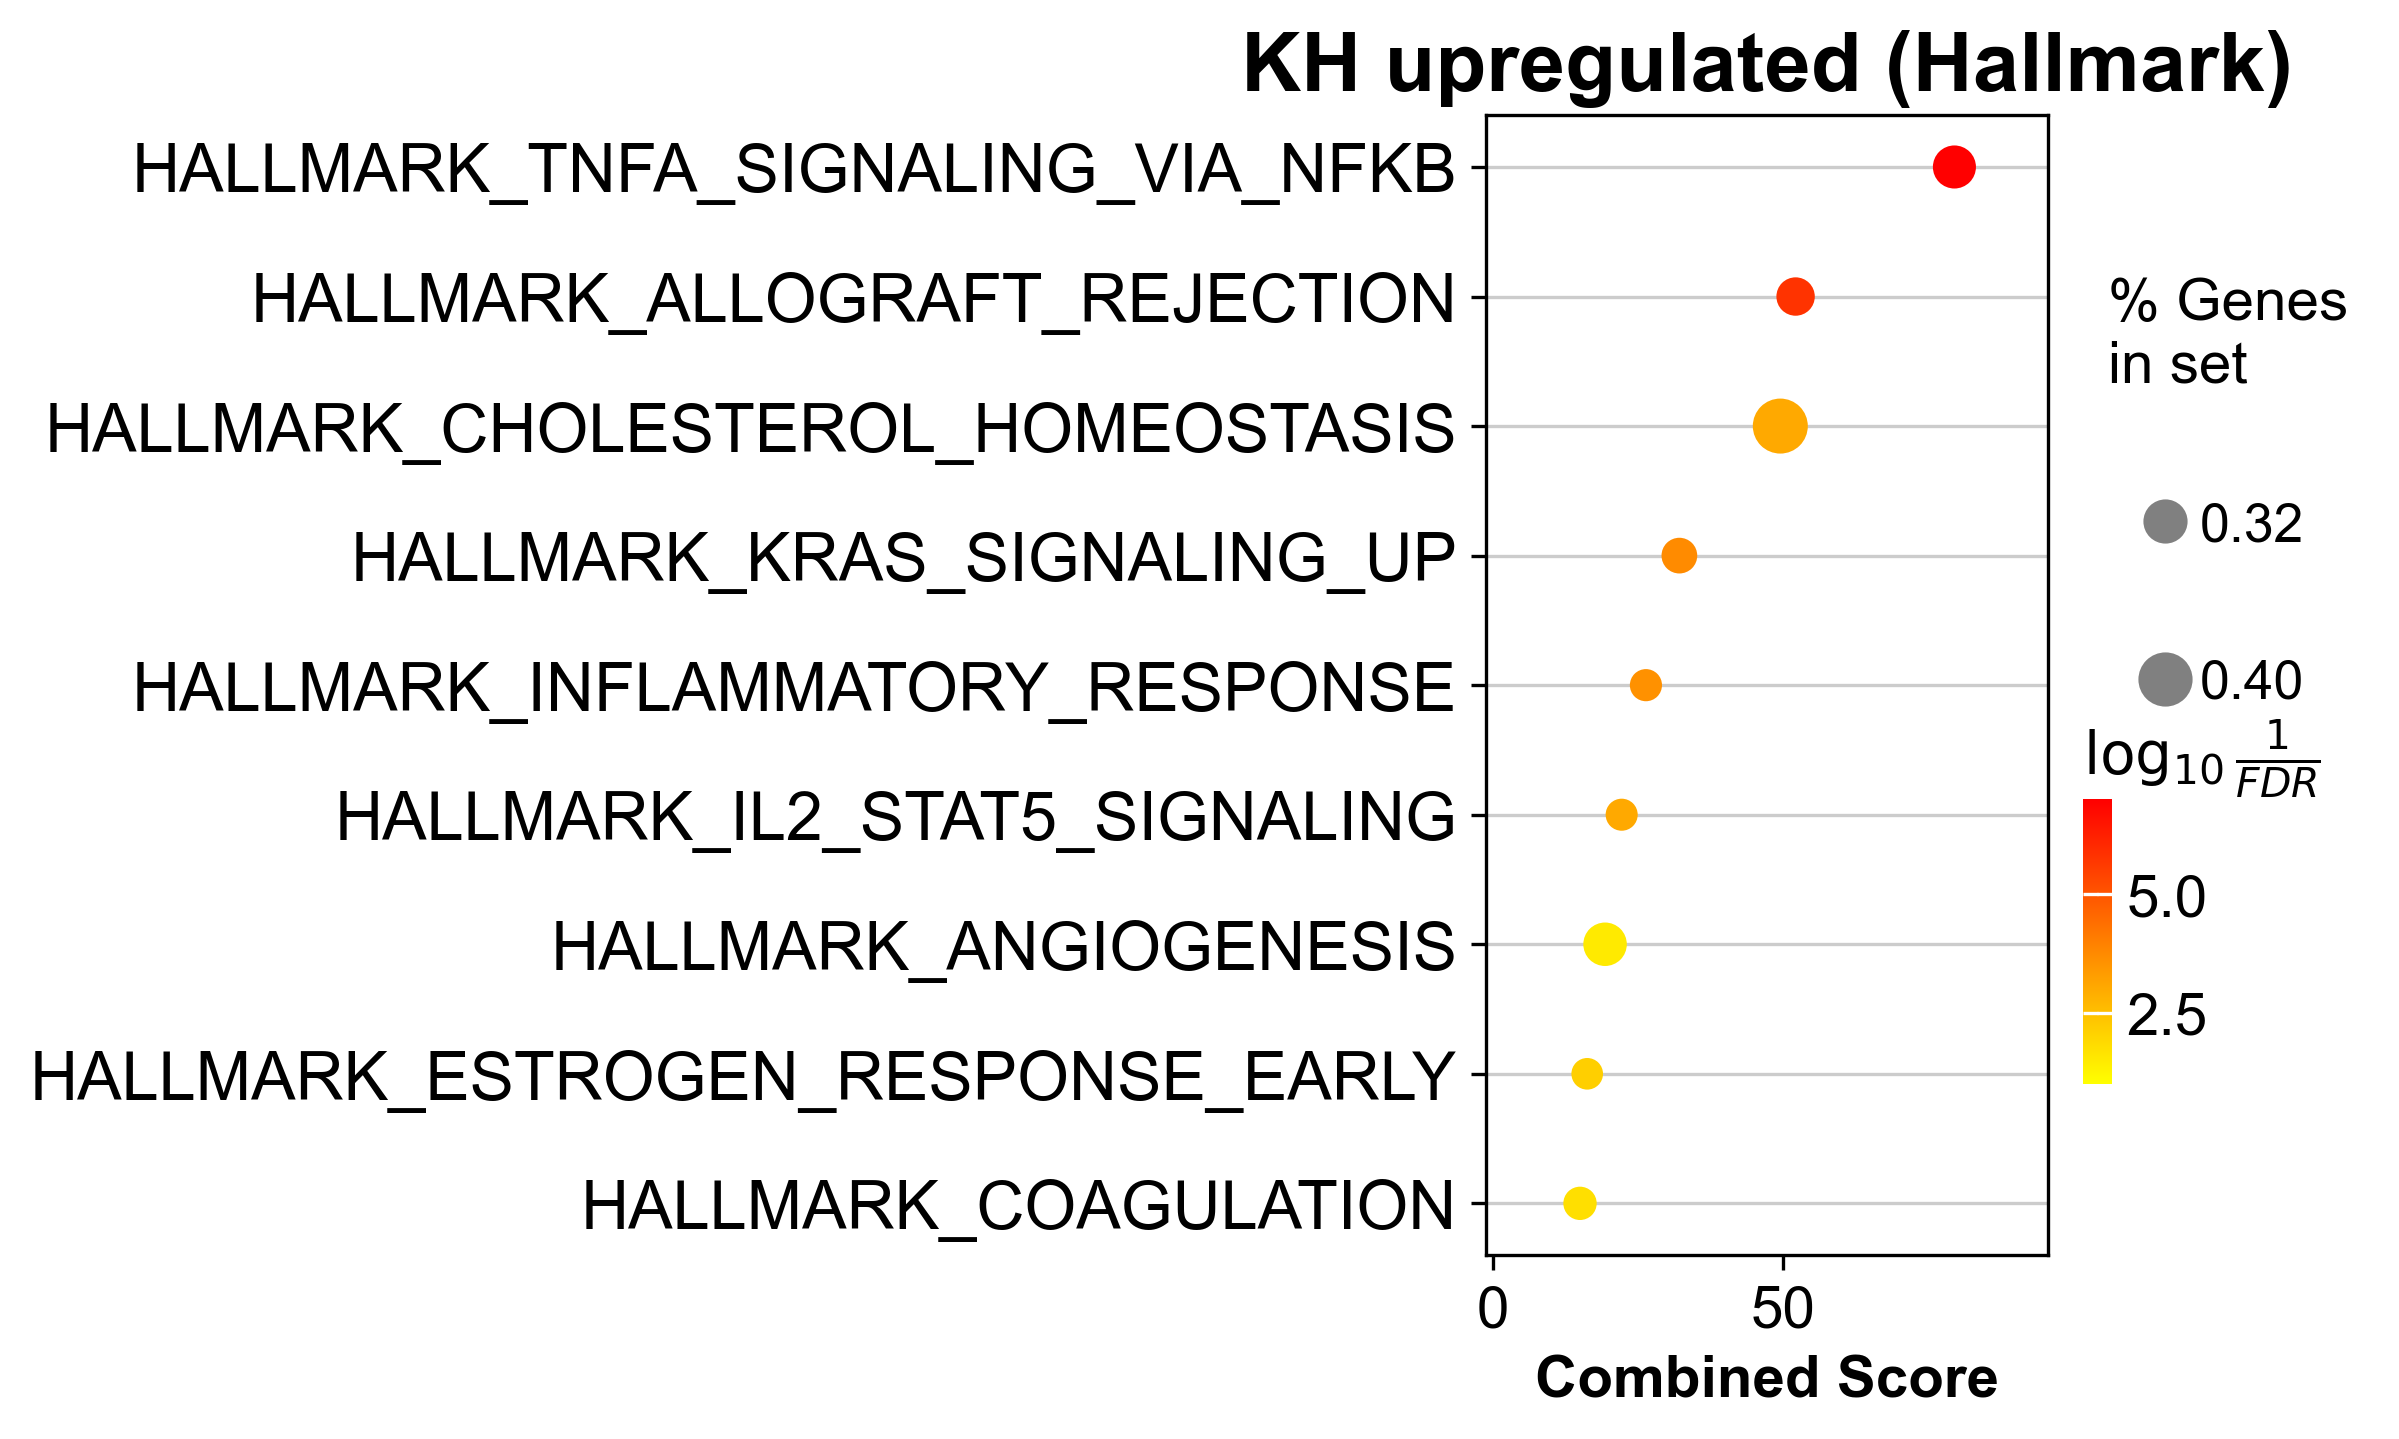

In [9]:
enr_upkh = gp.enrichr(kh_up, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_upkh.res2d, figsize=(3, 5), title='KH upregulated (Hallmark)', cmap=plt.cm.autumn_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


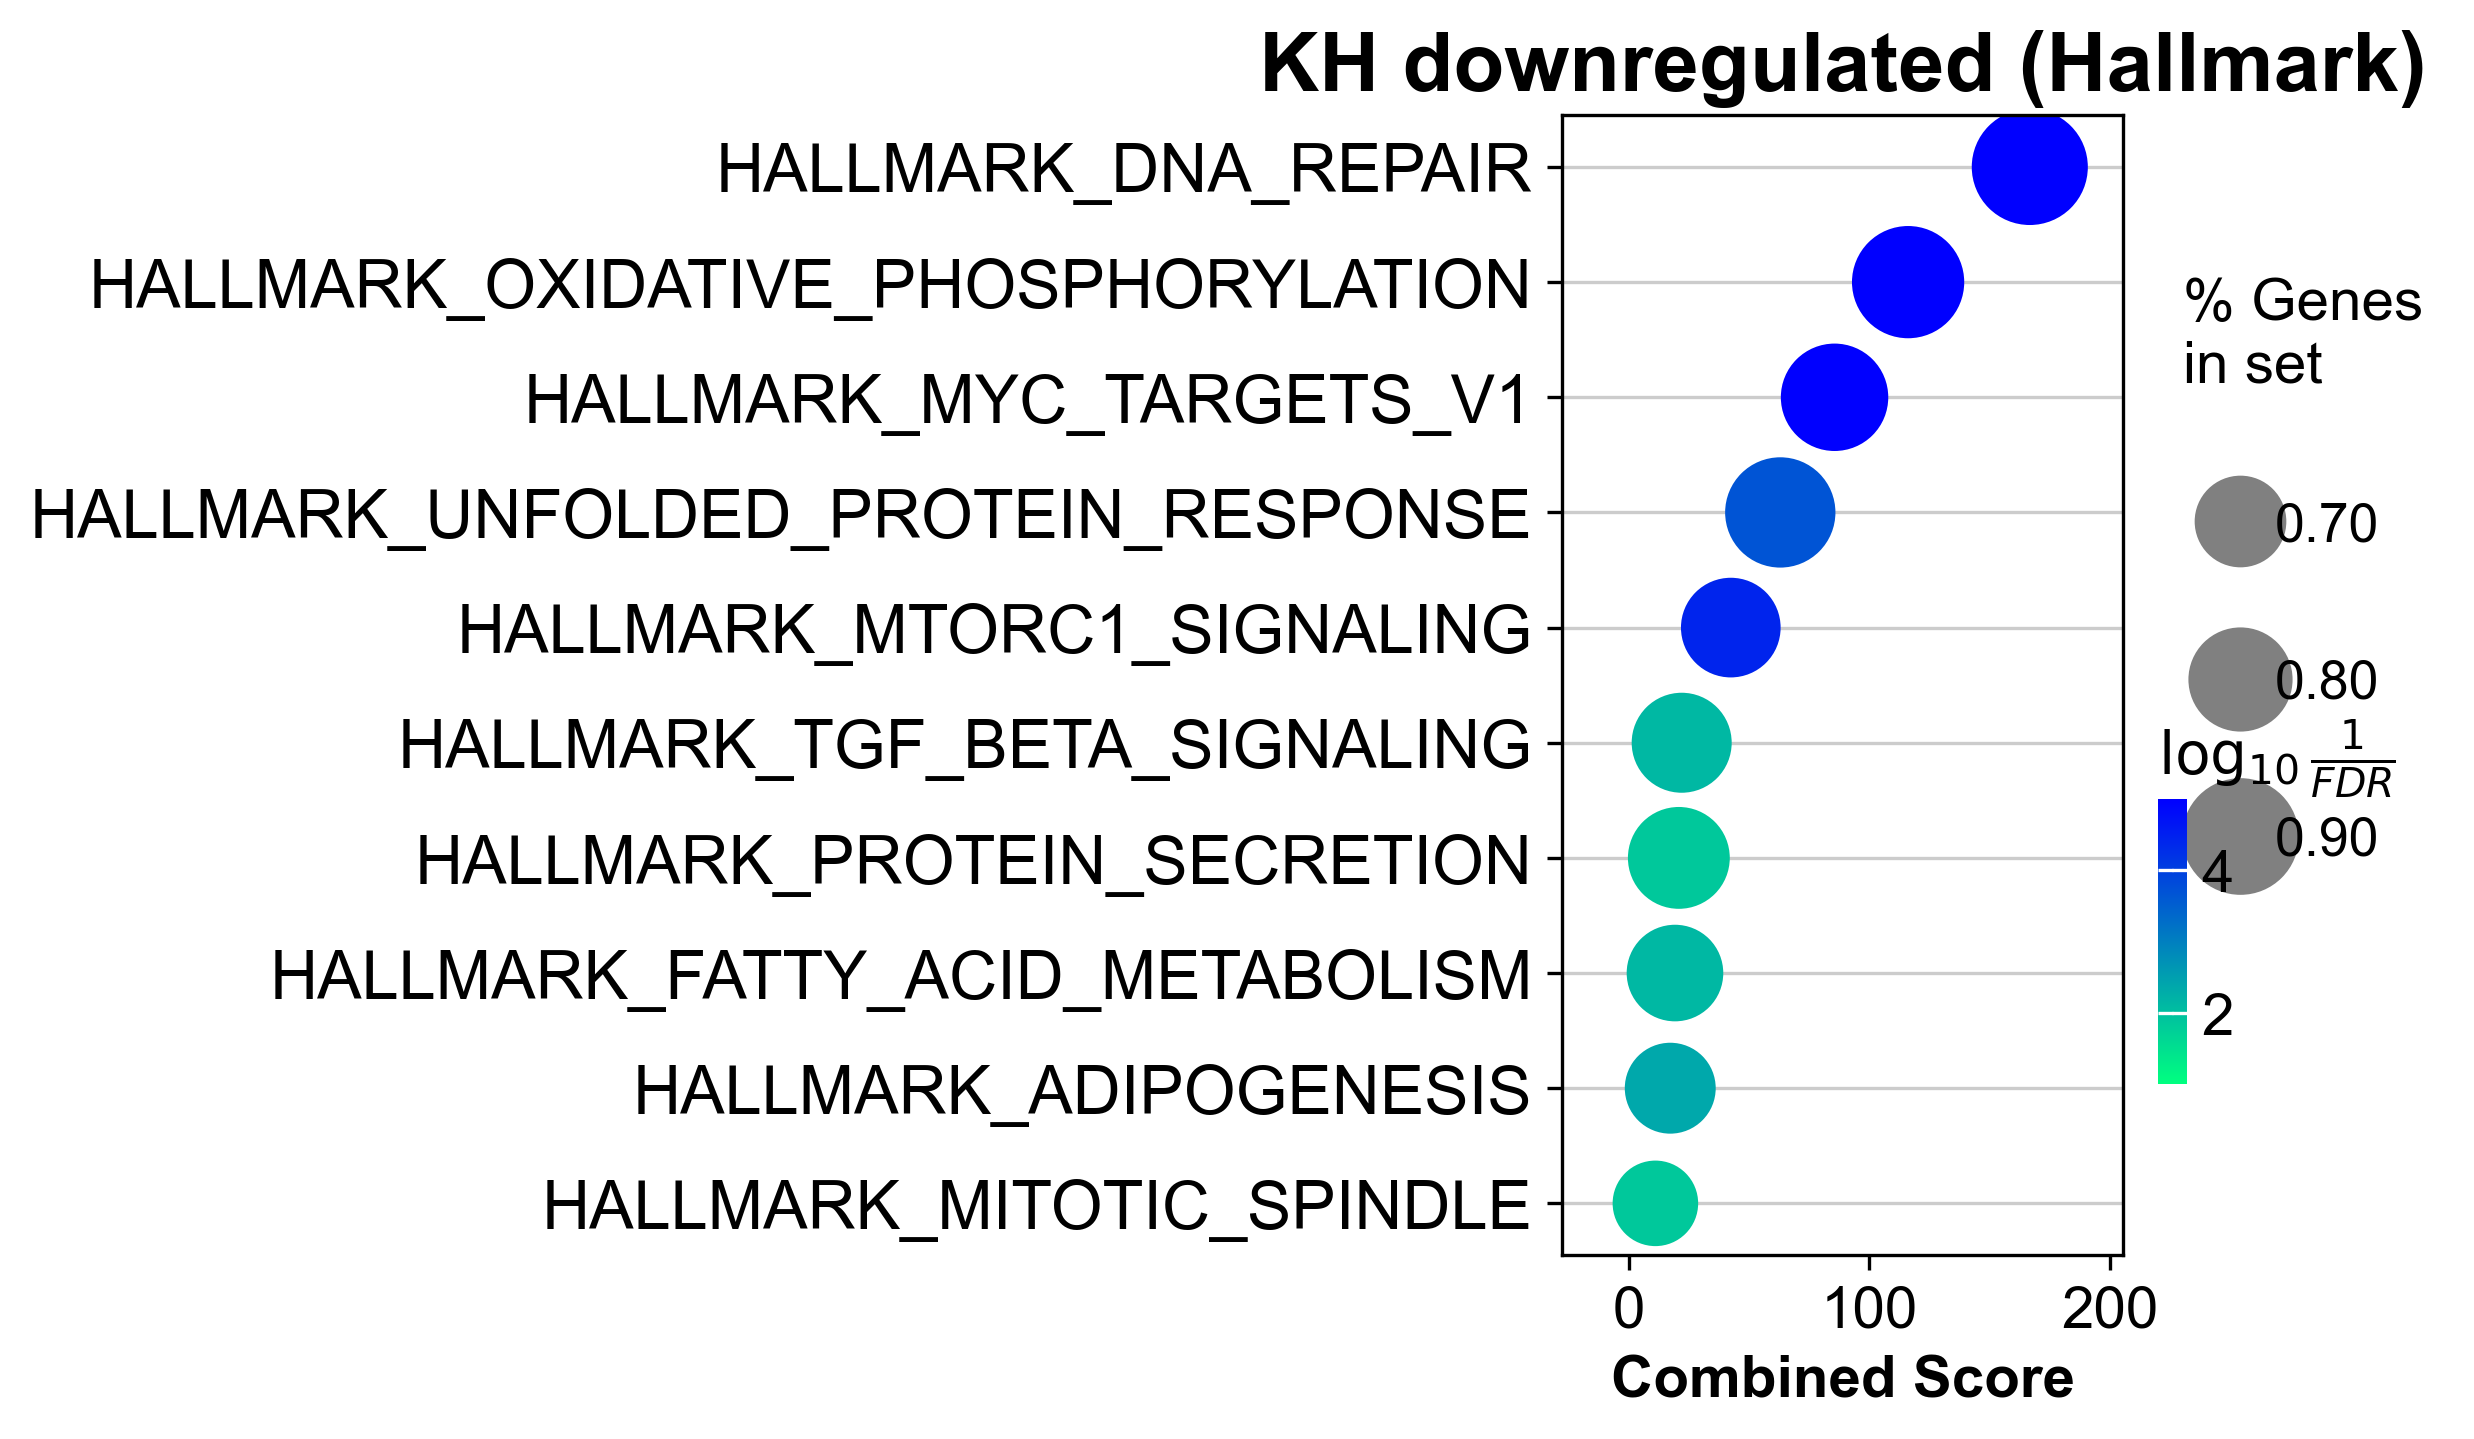

In [10]:
enr_dwkh = gp.enrichr(kh_down, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_dwkh.res2d, figsize=(3, 5), title='KH downregulated (Hallmark)', cmap=plt.cm.winter_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


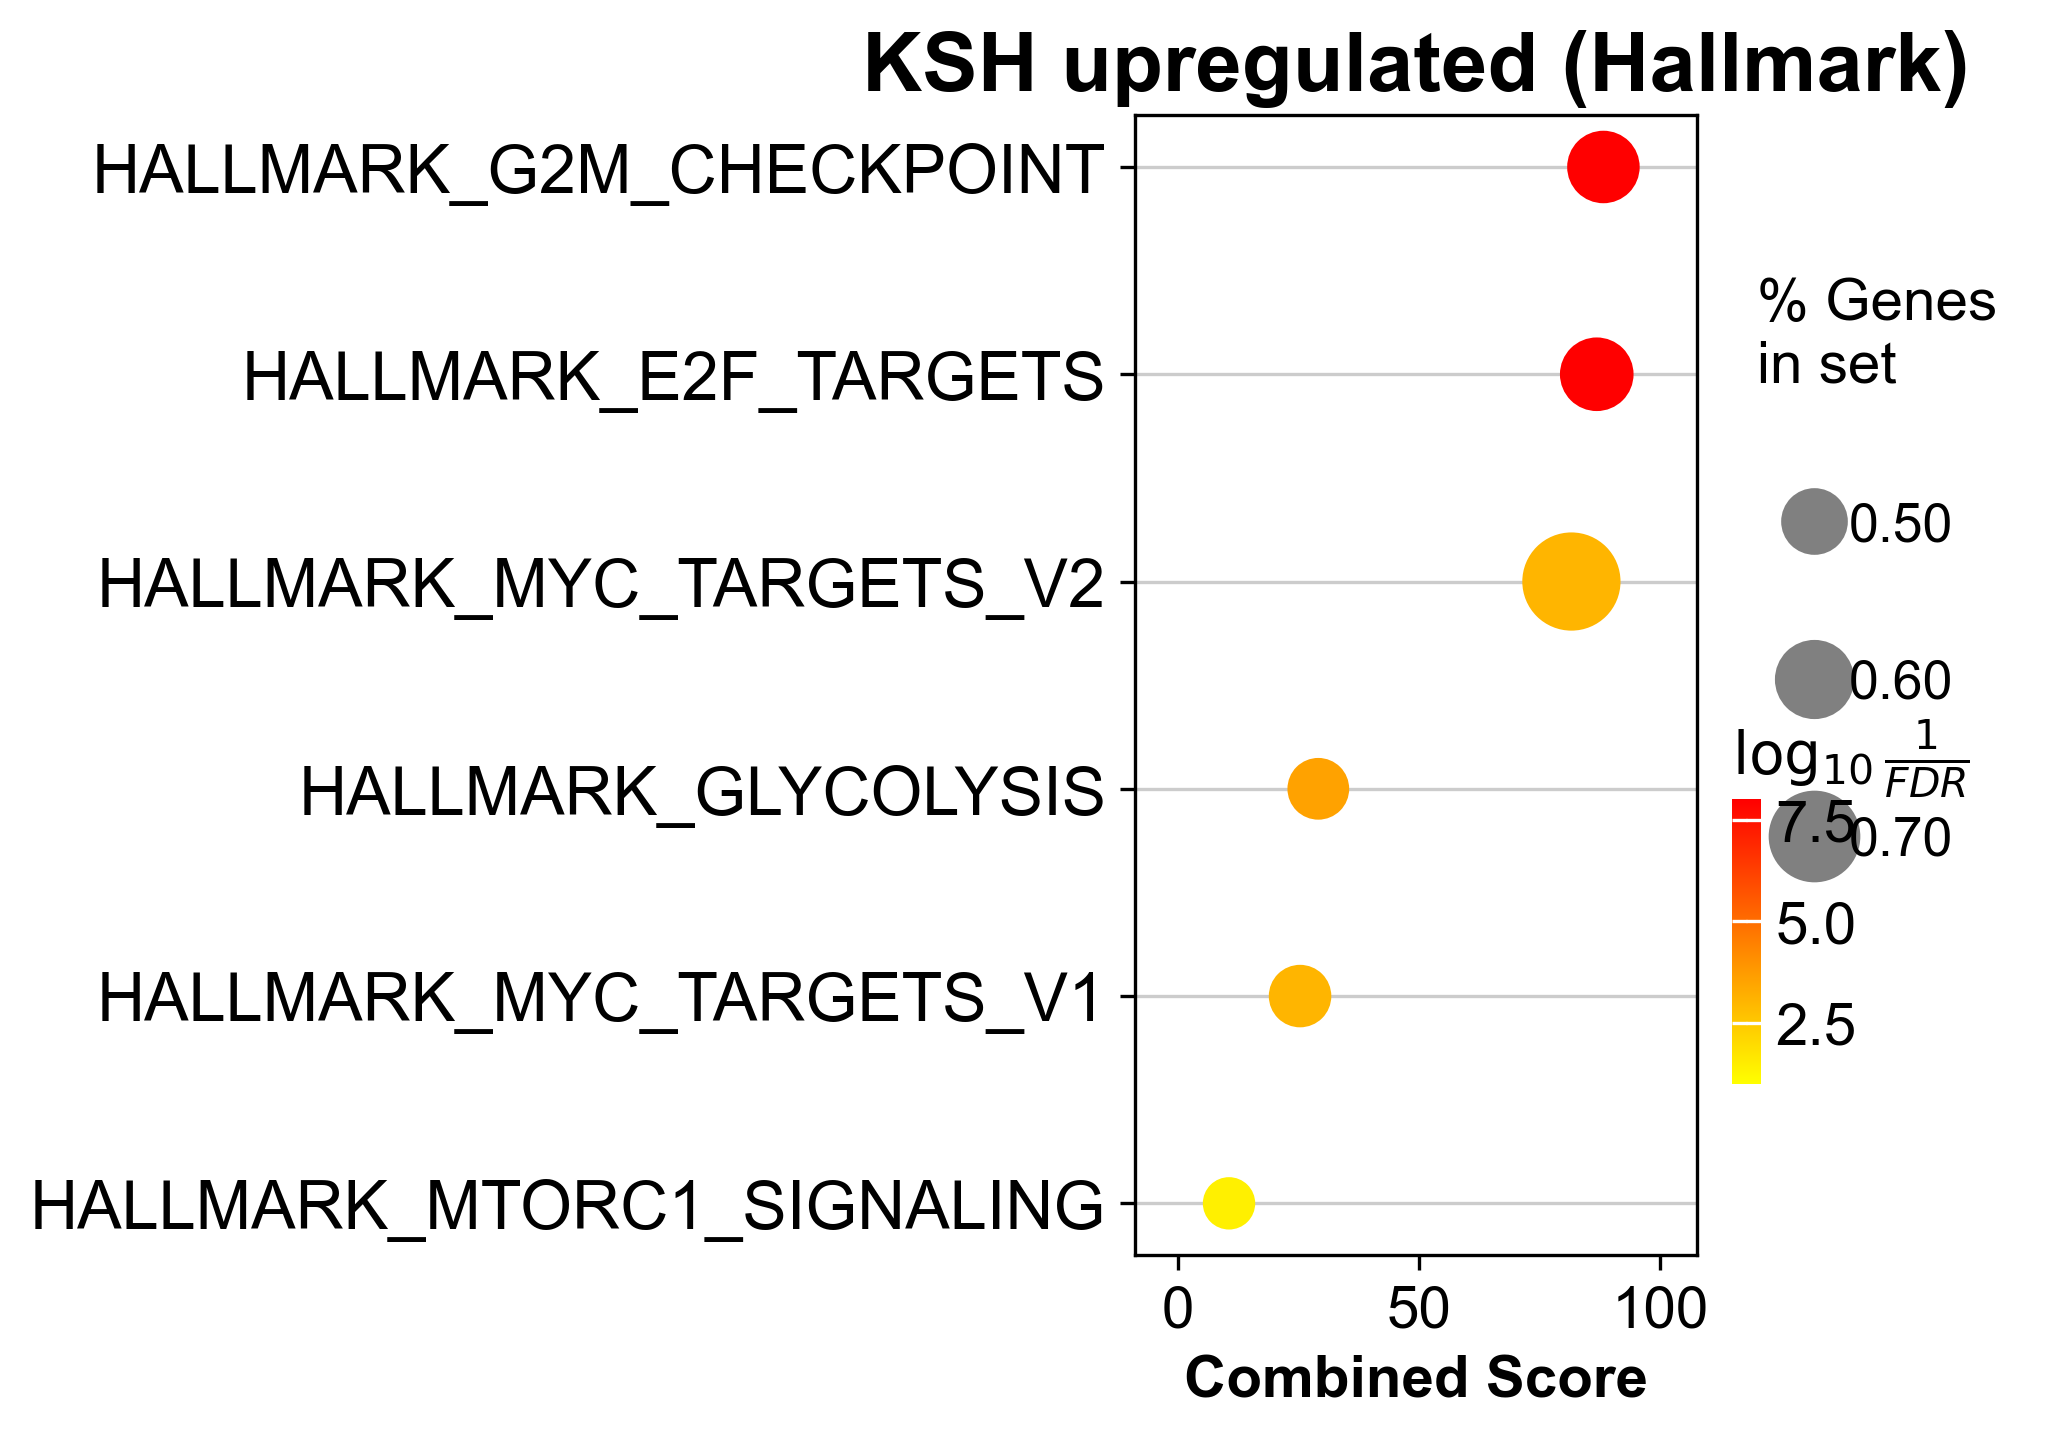

In [11]:
enr_upksh = gp.enrichr(ksh_up, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_upksh.res2d, figsize=(3, 5), title='KSH upregulated (Hallmark)', cmap=plt.cm.autumn_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


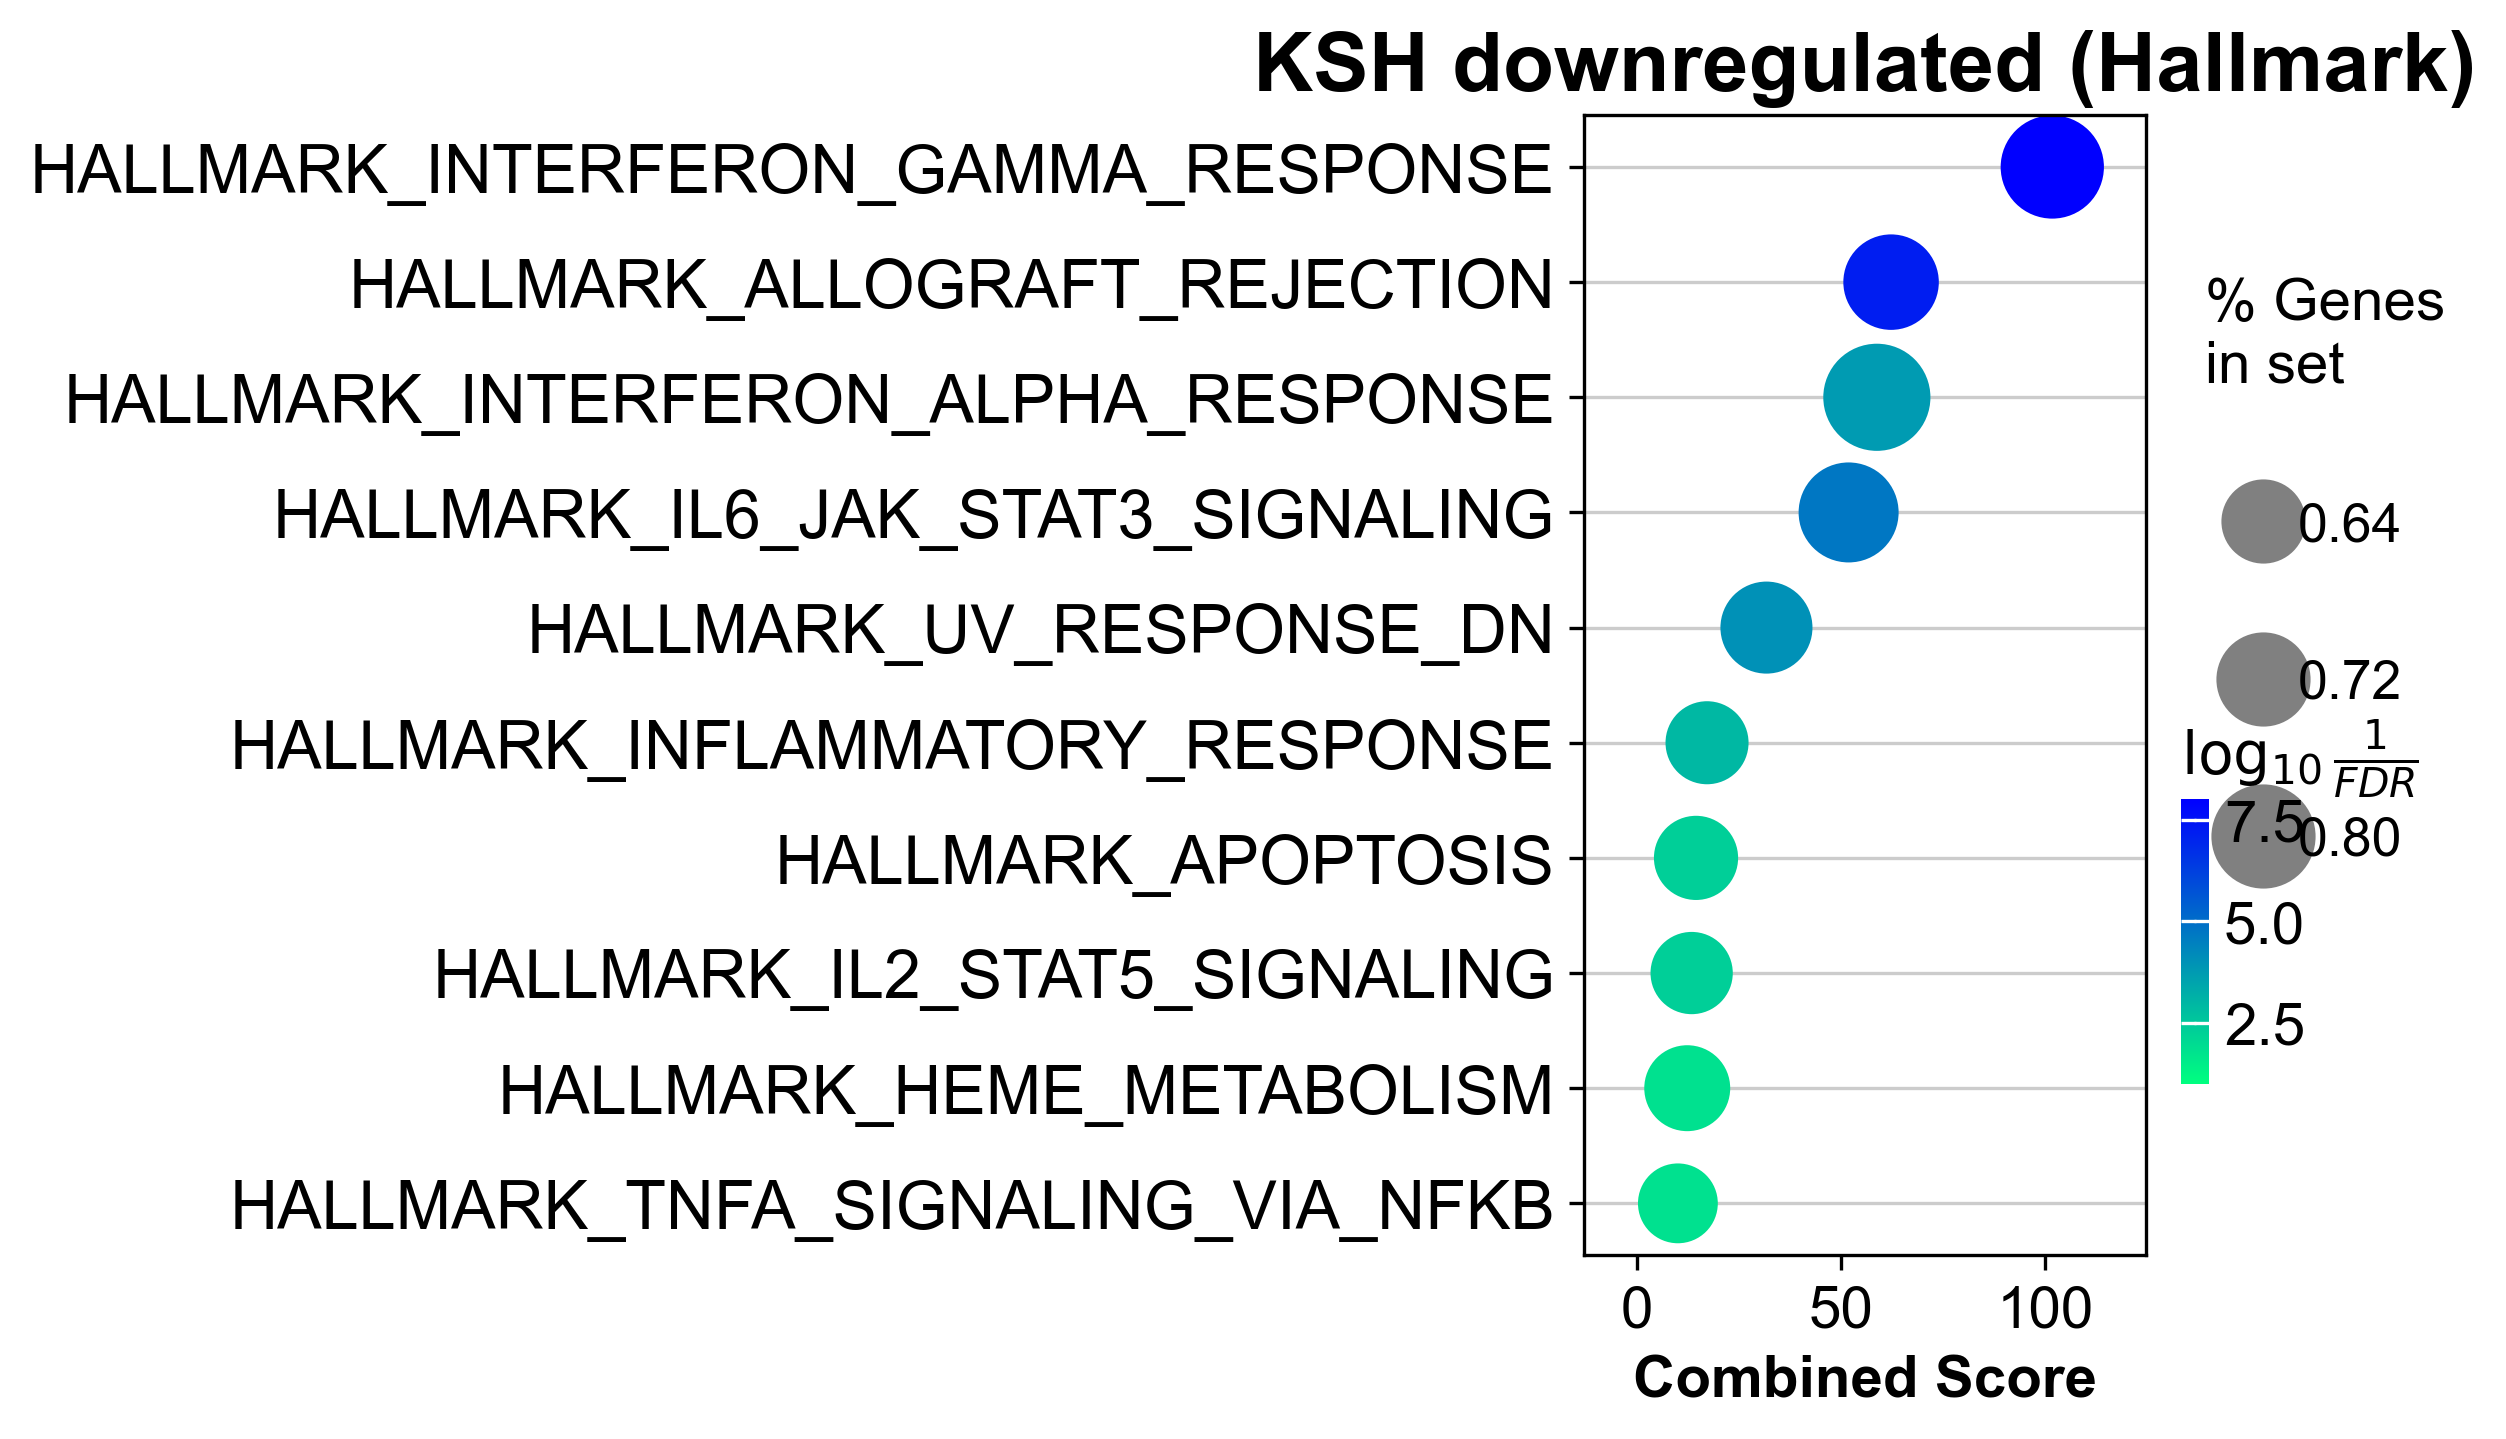

In [12]:
enr_dwksh = gp.enrichr(ksh_down, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_dwksh.res2d, figsize=(3, 5), title='KSH downregulated (Hallmark)', cmap=plt.cm.winter_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


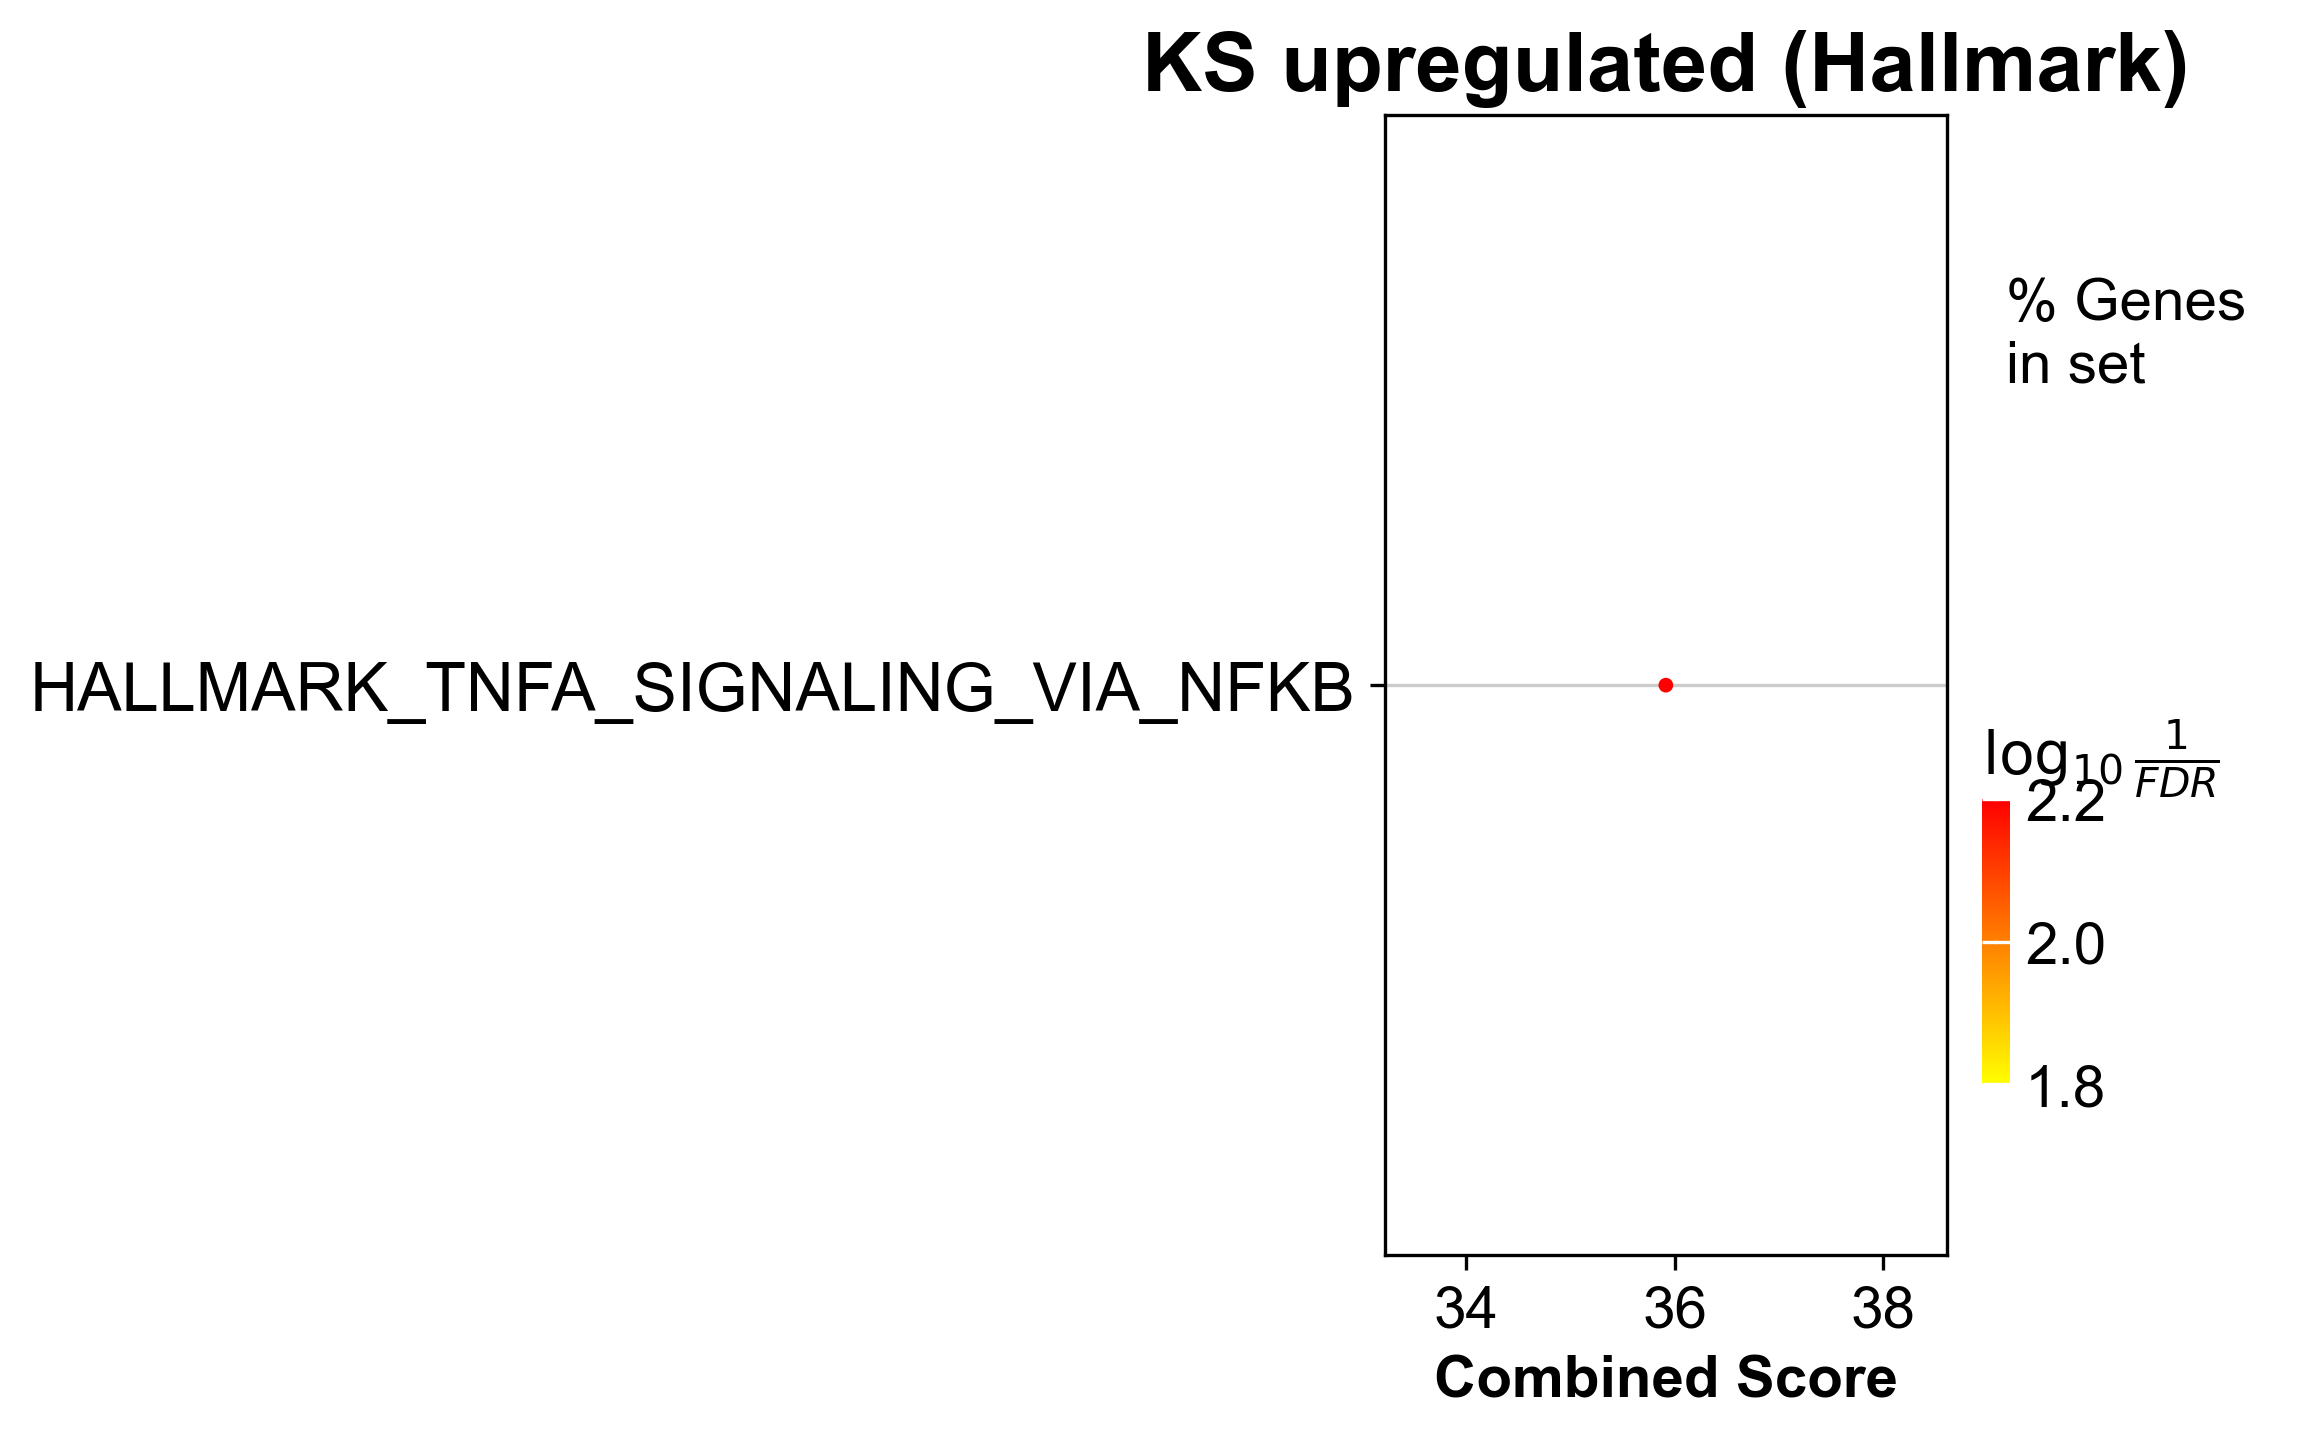

In [13]:
enr_upks = gp.enrichr(ks_up, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_upks.res2d, figsize=(3, 5), title='KS upregulated (Hallmark)', cmap=plt.cm.autumn_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


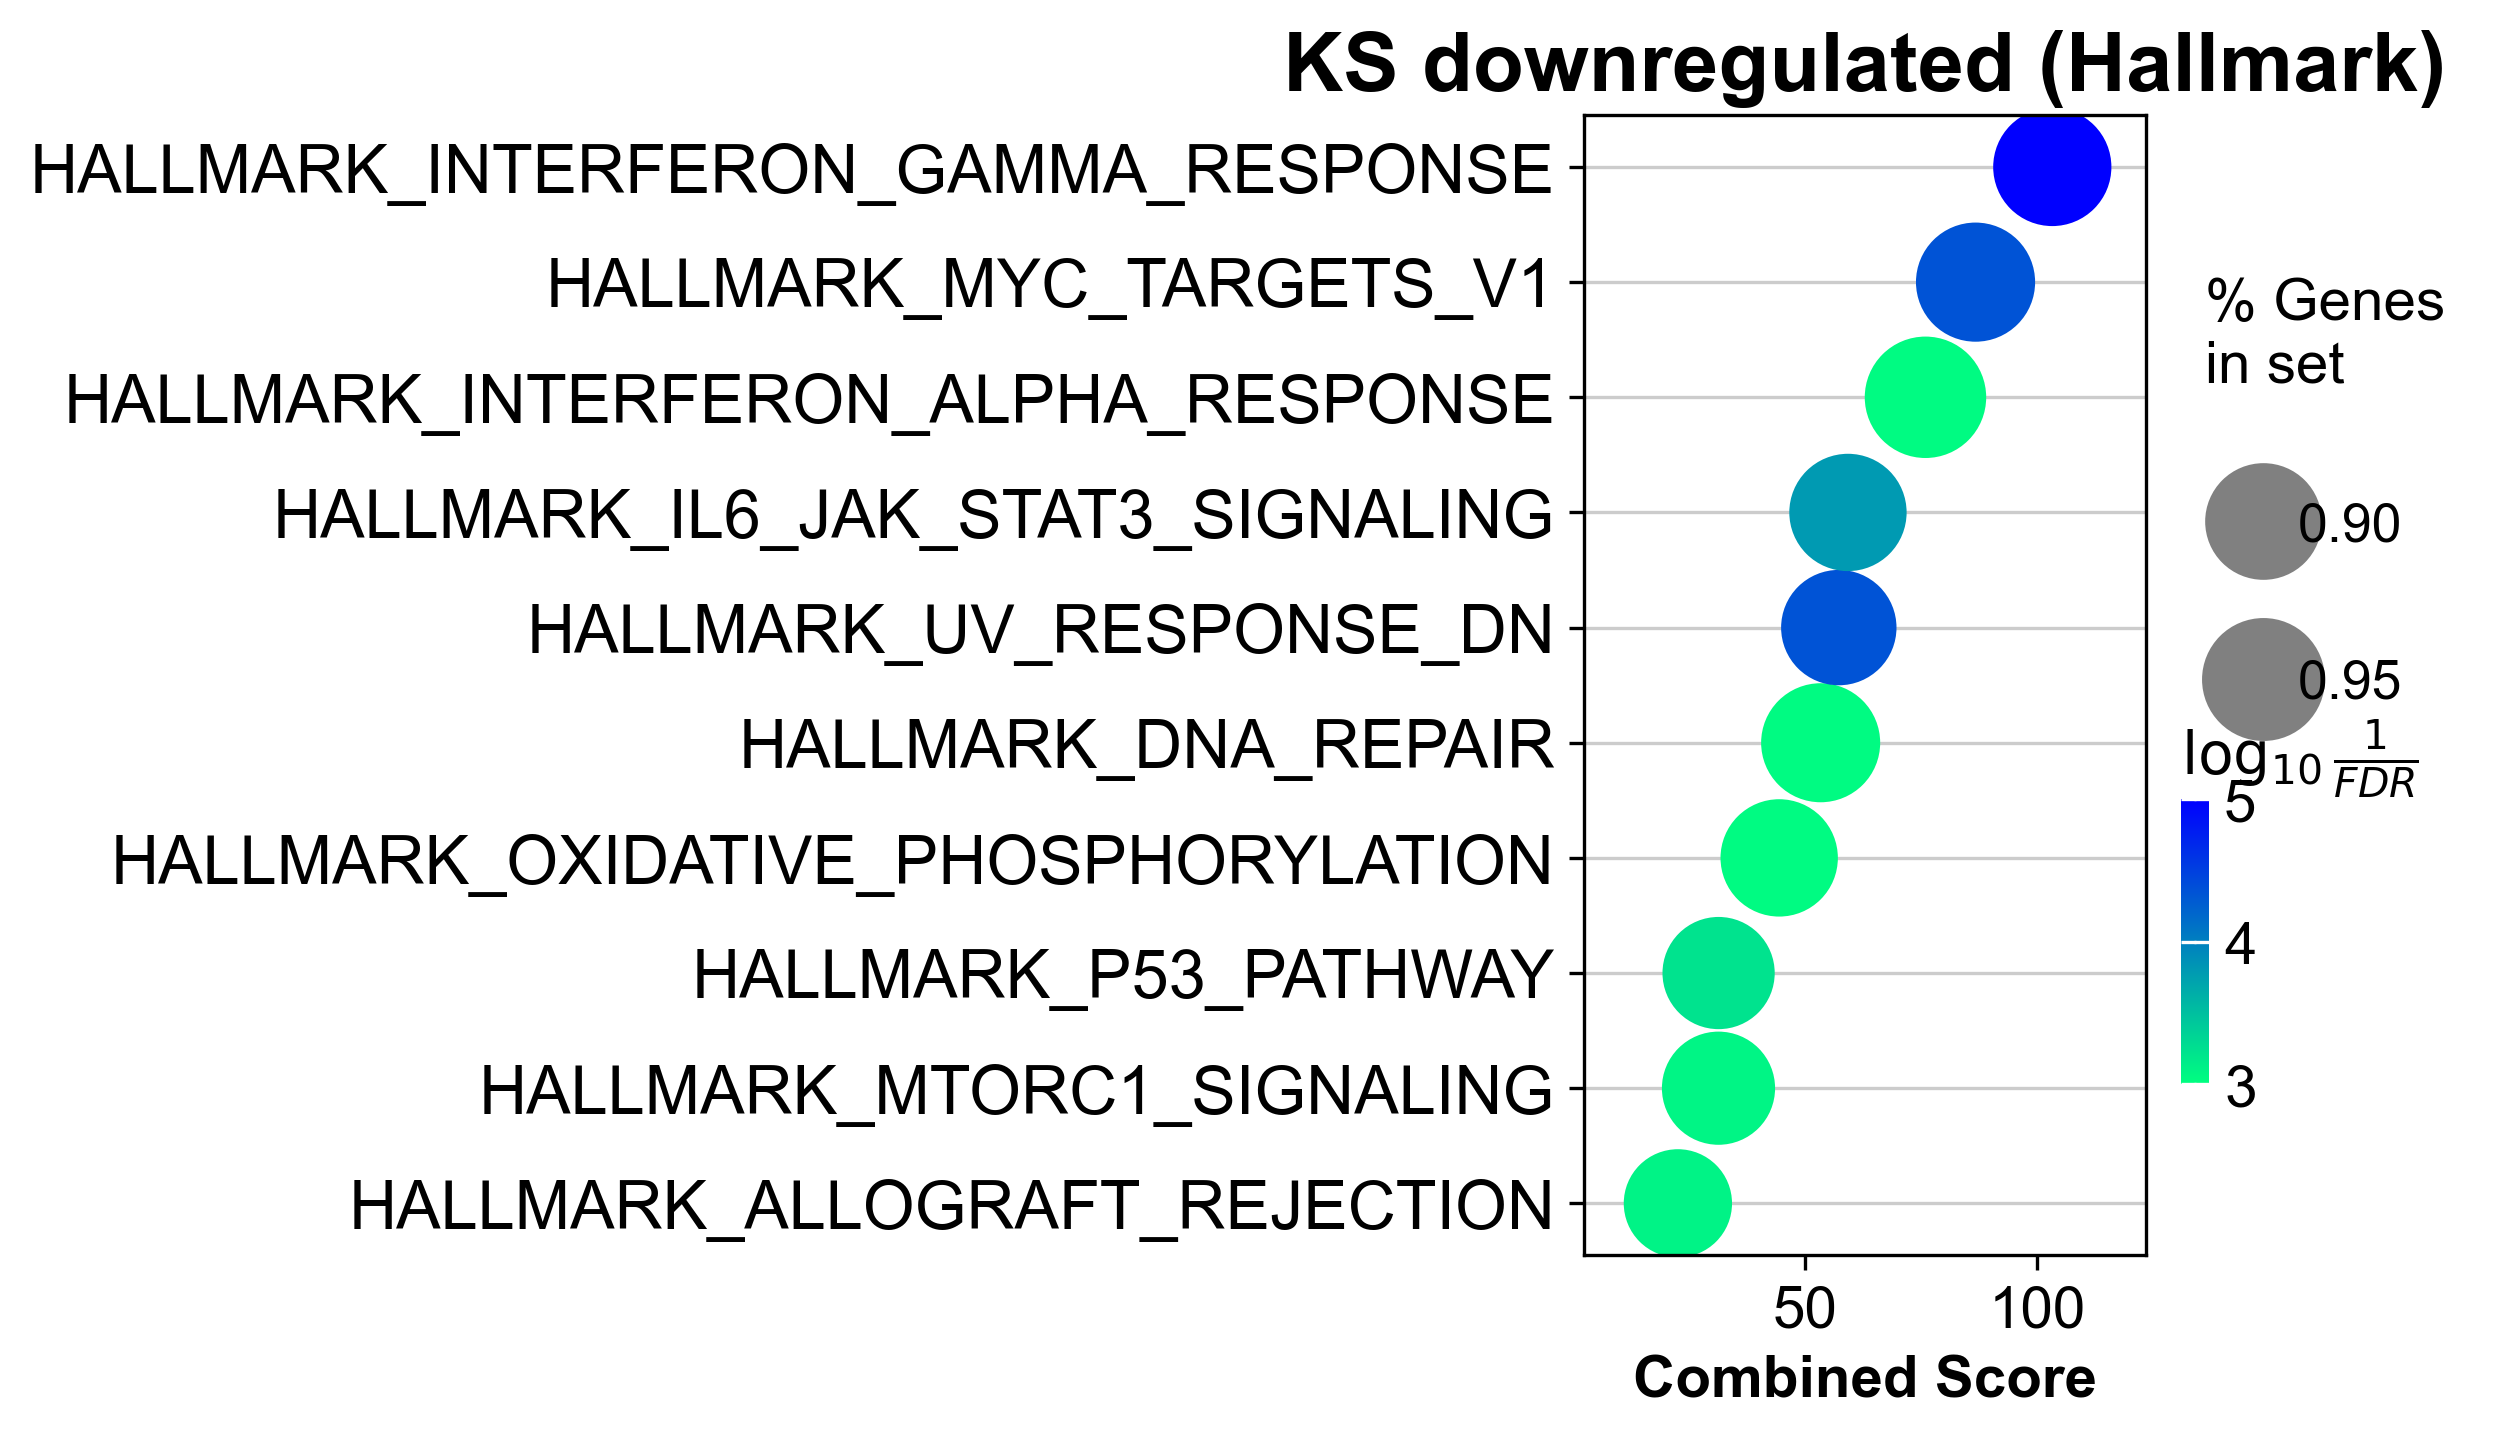

In [14]:
enr_dwks = gp.enrichr(ks_down, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_dwks.res2d, figsize=(3, 5), title='KS downregulated (Hallmark)', cmap=plt.cm.winter_r)
plt.show()

## Figure 2e — immune Hallmark scatter by genotype

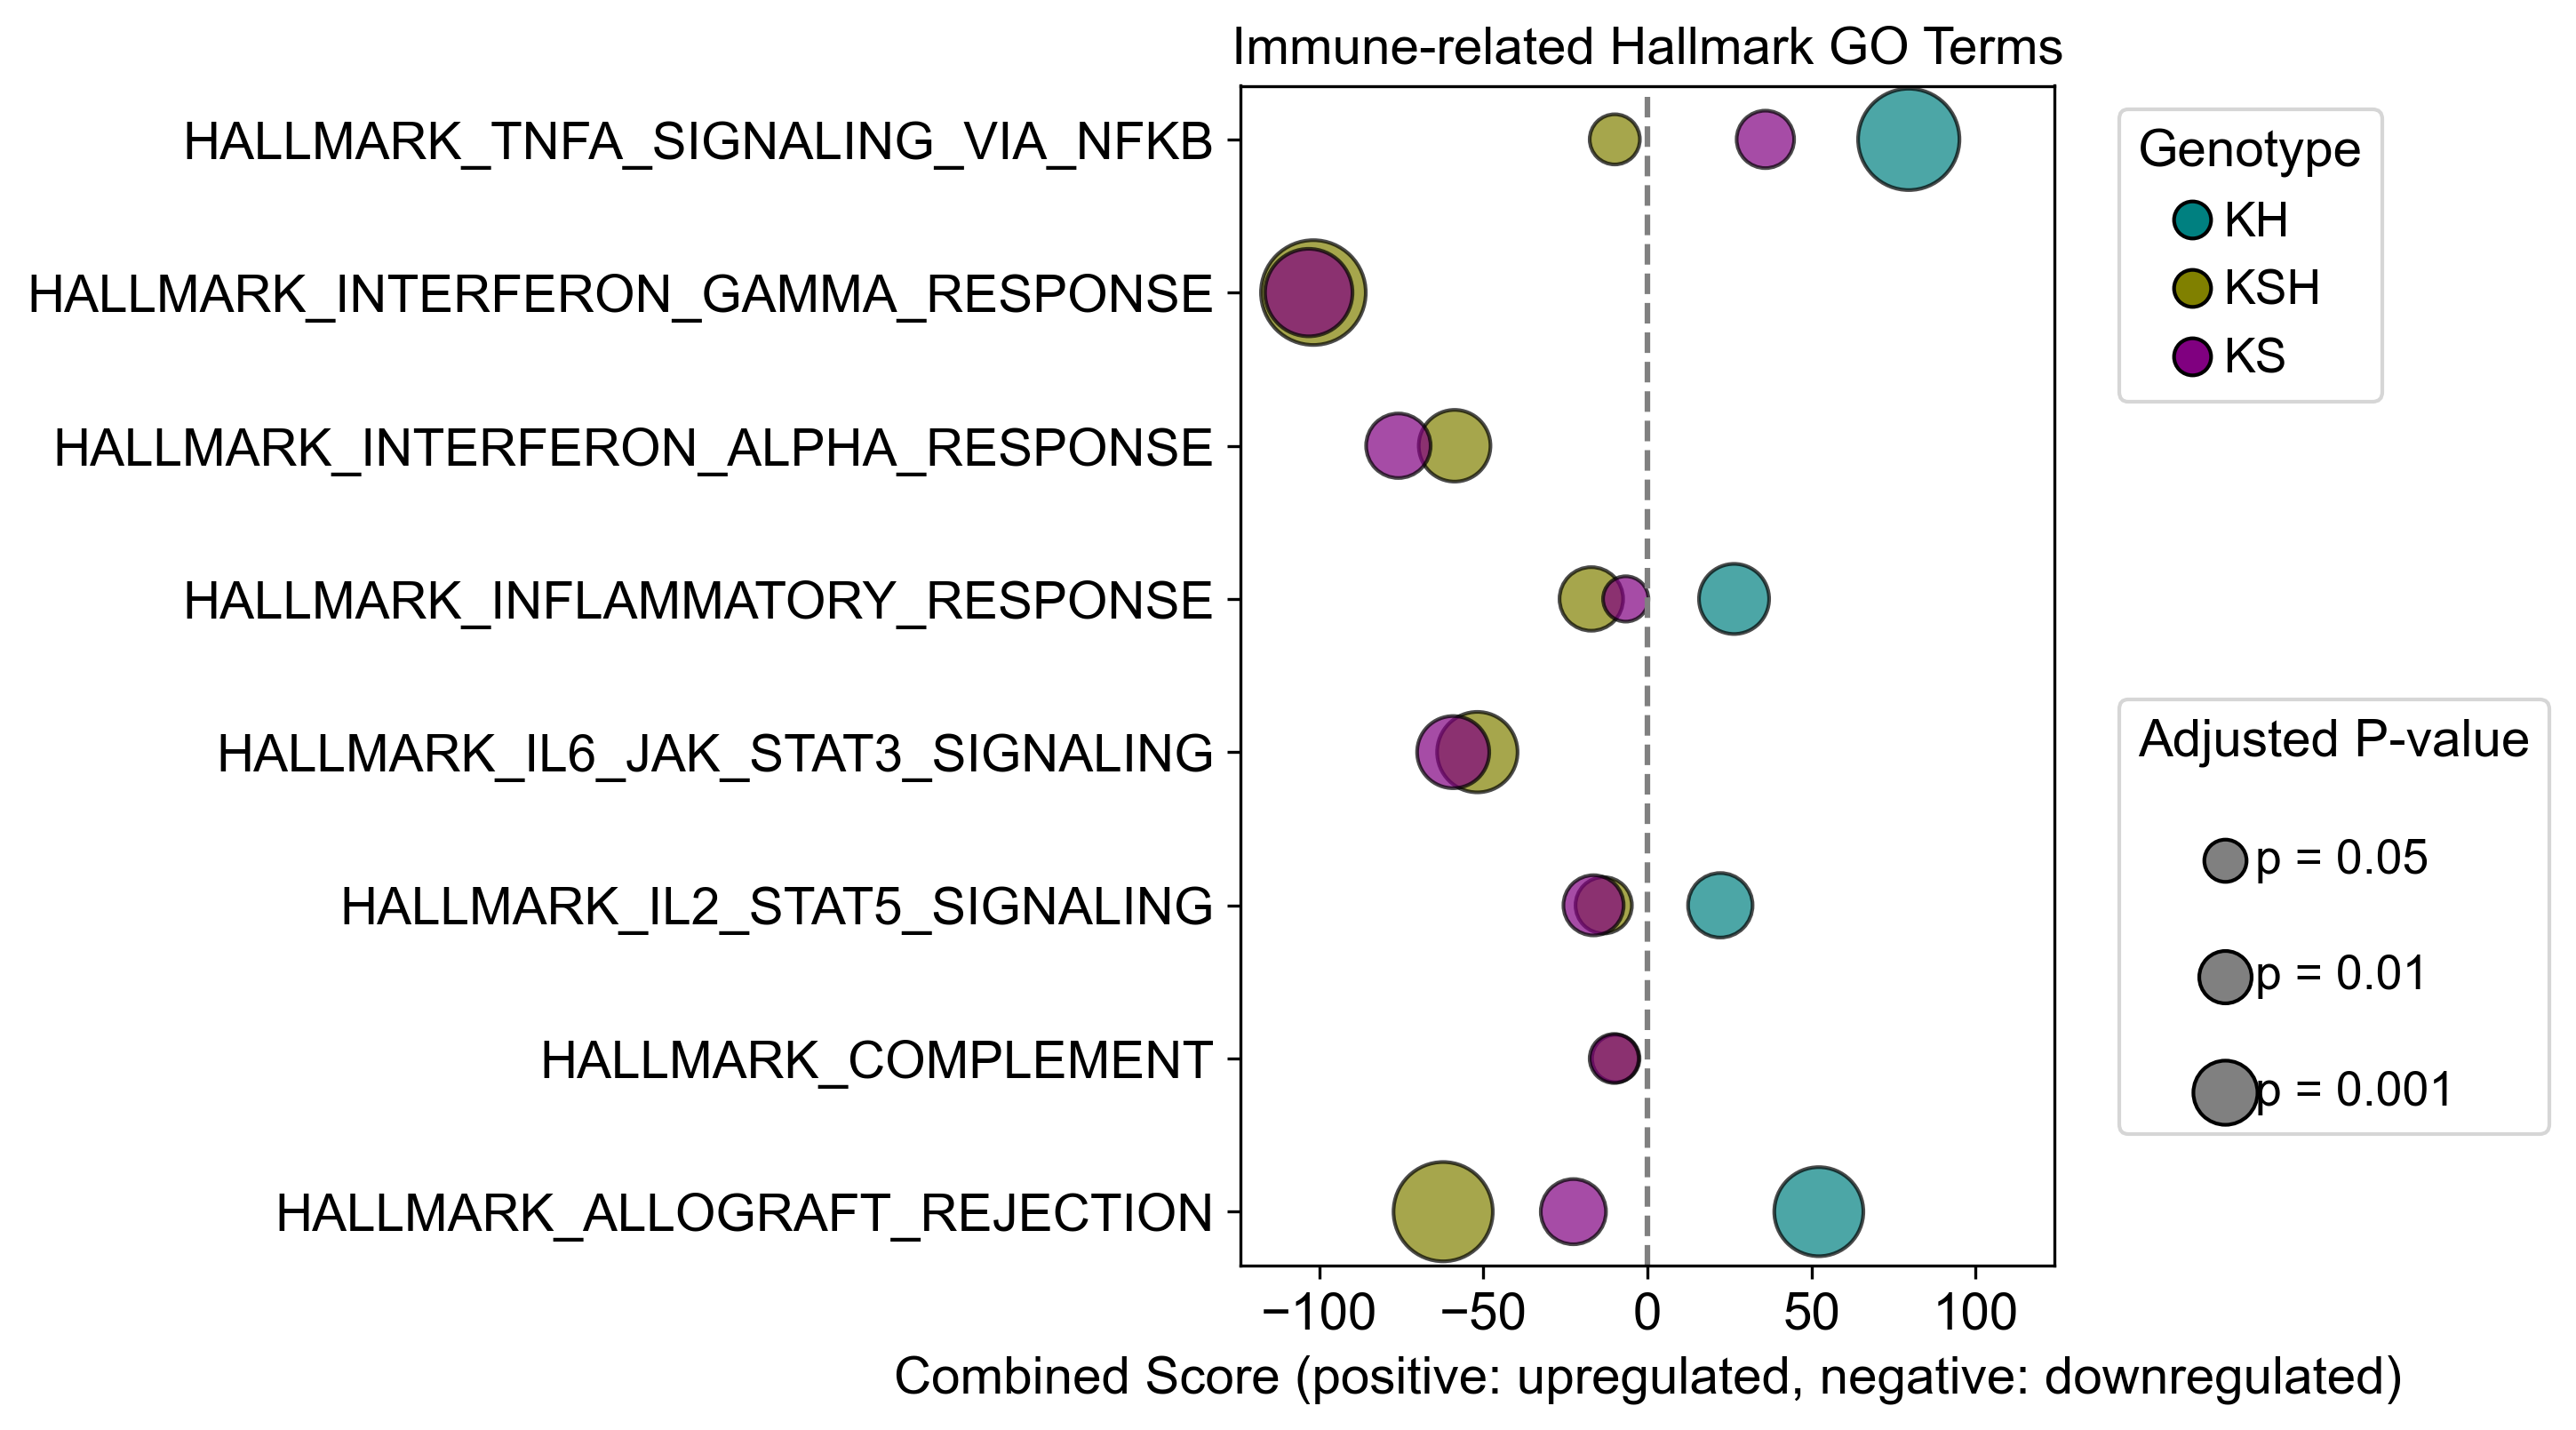

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df_upkh = enr_upkh.res2d.copy()
df_upkh['Direction'] = 'up'
df_upkh['Genotype'] = 'KH'

df_dwkh = enr_dwkh.res2d.copy()
df_dwkh['Direction'] = 'down'
df_dwkh['Genotype'] = 'KH'

df_upksh = enr_upksh.res2d.copy()
df_upksh['Direction'] = 'up'
df_upksh['Genotype'] = 'KSH'

df_dwksh = enr_dwksh.res2d.copy()
df_dwksh['Direction'] = 'down'
df_dwksh['Genotype'] = 'KSH'

df_upks = enr_upks.res2d.copy()
df_upks['Direction'] = 'up'
df_upks['Genotype'] = 'KS'

df_dwks = enr_dwks.res2d.copy()
df_dwks['Direction'] = 'down'
df_dwks['Genotype'] = 'KS'

df_upkh = df_upkh[df_upkh['Adjusted P-value'] < 0.05]
df_dwkh = df_dwkh[df_dwkh['Adjusted P-value'] < 0.05]
df_upksh = df_upksh[df_upksh['Adjusted P-value'] < 0.05]
df_dwksh = df_dwksh[df_dwksh['Adjusted P-value'] < 0.05]
df_upks = df_upks[df_upks['Adjusted P-value'] < 0.05]
df_dwks = df_dwks[df_dwks['Adjusted P-value'] < 0.05]

df_all = pd.concat([df_upkh, df_dwkh, df_upksh, df_dwksh, df_upks, df_dwks], ignore_index=True)

df_all['plot_score'] = df_all.apply(
    lambda row: np.abs(row['Combined Score']) if row['Direction'] == 'up'
                else -np.abs(row['Combined Score']),
    axis=1
)

scale_factor = 100
df_all['dot_size'] = -np.log10(df_all['Adjusted P-value']) * scale_factor

terms_to_keep = [
    "HALLMARK_INTERFERON_GAMMA_RESPONSE",
    "HALLMARK_ALLOGRAFT_REJECTION",
    "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    "HALLMARK_INTERFERON_ALPHA_RESPONSE",
    "HALLMARK_INFLAMMATORY_RESPONSE",
    "HALLMARK_IL2_STAT5_SIGNALING",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    "HALLMARK_COMPLEMENT"
]
df_subset = df_all[df_all['Term'].isin(terms_to_keep)].copy()

go_terms = sorted(df_subset['Term'].unique())
term_to_y = {term: i for i, term in enumerate(go_terms)}
df_subset['y_pos'] = df_subset['Term'].map(term_to_y)

plt.figure(figsize=(10, len(go_terms) * 0.7))

genotype_colors = {'KH': 'teal', 'KSH': 'olive', 'KS': 'purple'}

for genotype, color in genotype_colors.items():
    subset = df_subset[df_subset['Genotype'] == genotype]
    plt.scatter(subset['plot_score'], subset['y_pos'],
                s=subset['dot_size'], color=color,
                alpha=0.7, edgecolors='k', label=genotype)

plt.axvline(0, color='gray', linestyle='--')

max_val = np.ceil(np.abs(df_subset['plot_score']).max() * 1.2)
plt.xlim(-max_val, max_val)

plt.yticks(range(len(go_terms)), go_terms)
plt.xlabel('Combined Score (positive: upregulated, negative: downregulated)')
plt.ylabel('')
plt.title('Immune-related Hallmark GO Terms')

genotype_handles = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color, markersize=10,
                           markeredgecolor='k', label=genotype)
                    for genotype, color in genotype_colors.items()]

example_pvals = [0.05, 0.01, 0.001]
size_handles = [plt.scatter([], [], s=-np.log10(p) * scale_factor,
                            color='gray', edgecolors='k')
                for p in example_pvals]
size_labels = [f'p = {p}' for p in example_pvals]

legend1 = plt.legend(handles=genotype_handles, title='Genotype',
                     bbox_to_anchor=(1.05, 1), loc='upper left')
legend2 = plt.legend(size_handles, size_labels, scatterpoints=1,
                     title='Adjusted P-value', bbox_to_anchor=(1.05, 0.5),
                     loc='upper left', labelspacing=1.5)
plt.gca().add_artist(legend1)

plt.subplots_adjust(right=0.75)
plt.tight_layout()

plt.savefig(os.path.join(outdir, "fig2e.svg"), format='svg')

plt.show()


## Module 6 enrichment — canonical pathways (ED4a)

In [16]:
mod6 = [
    'Chil1', 'Ly6i', 'C3', 'Hspa1b', 'Spib', 'Cd44', 'Isg15', 'Gabrp',
    'Slc26a4', 'Oasl2', 'Ly6k', 'Tbx1', 'H2-DMb2', 'Rragd', 'Ifit1', 'Cftr',
    'Gbp2b', 'Piezo2', 'Rnaset2a', 'Pdia3', 'Nkx2-2', 'Ifit3', 'Cfb', 'Cd55',
    'Stat1', 'Usp18', 'Tap1', 'Plxnb2', 'Icam1', 'Il18rap', 'Wnt10a', 'Nid2',
    'Gbp2', 'Ofd1', 'Trib3', 'Ezr', 'Sdc1', 'Atf4', 'Cnga2', 'Cxcl9',
    'Tnfrsf11a', 'Bcl2a1a', 'Tacstd2', 'Ugt8a', 'Ptchd1', 'Muc20', 'Msln', 'Ifi44',
    'Bhlhe40', 'Cav2', 'Syk', 'Gfra1', 'Cadm1', 'Gdf10', 'Pcdh10', 'Map1lc3a',
    'Lgals9', 'Plk2', 'Igtp', 'Arg2', 'Tnfrsf9', 'Rab27a', 'Ciita', 'Itga9',
    'Cdh1', 'Lama3', 'Lipm', 'Rec8', 'Sel1l', 'Vcl', 'Osmr', 'Nfkb2',
    'Casp1', 'Tnfaip3', 'Sec1', 'Hdac9', 'Tnfsf13', 'Msn', 'Prom2', 'Clic3',
    'Casp4', 'Igha', 'Hsph1', 'Gbp3', 'Malt1', 'Cxcl10', 'Cxcl1', 'Tnc',
    'Ifi27', 'Cdkn1a', 'B4galnt1',
]

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


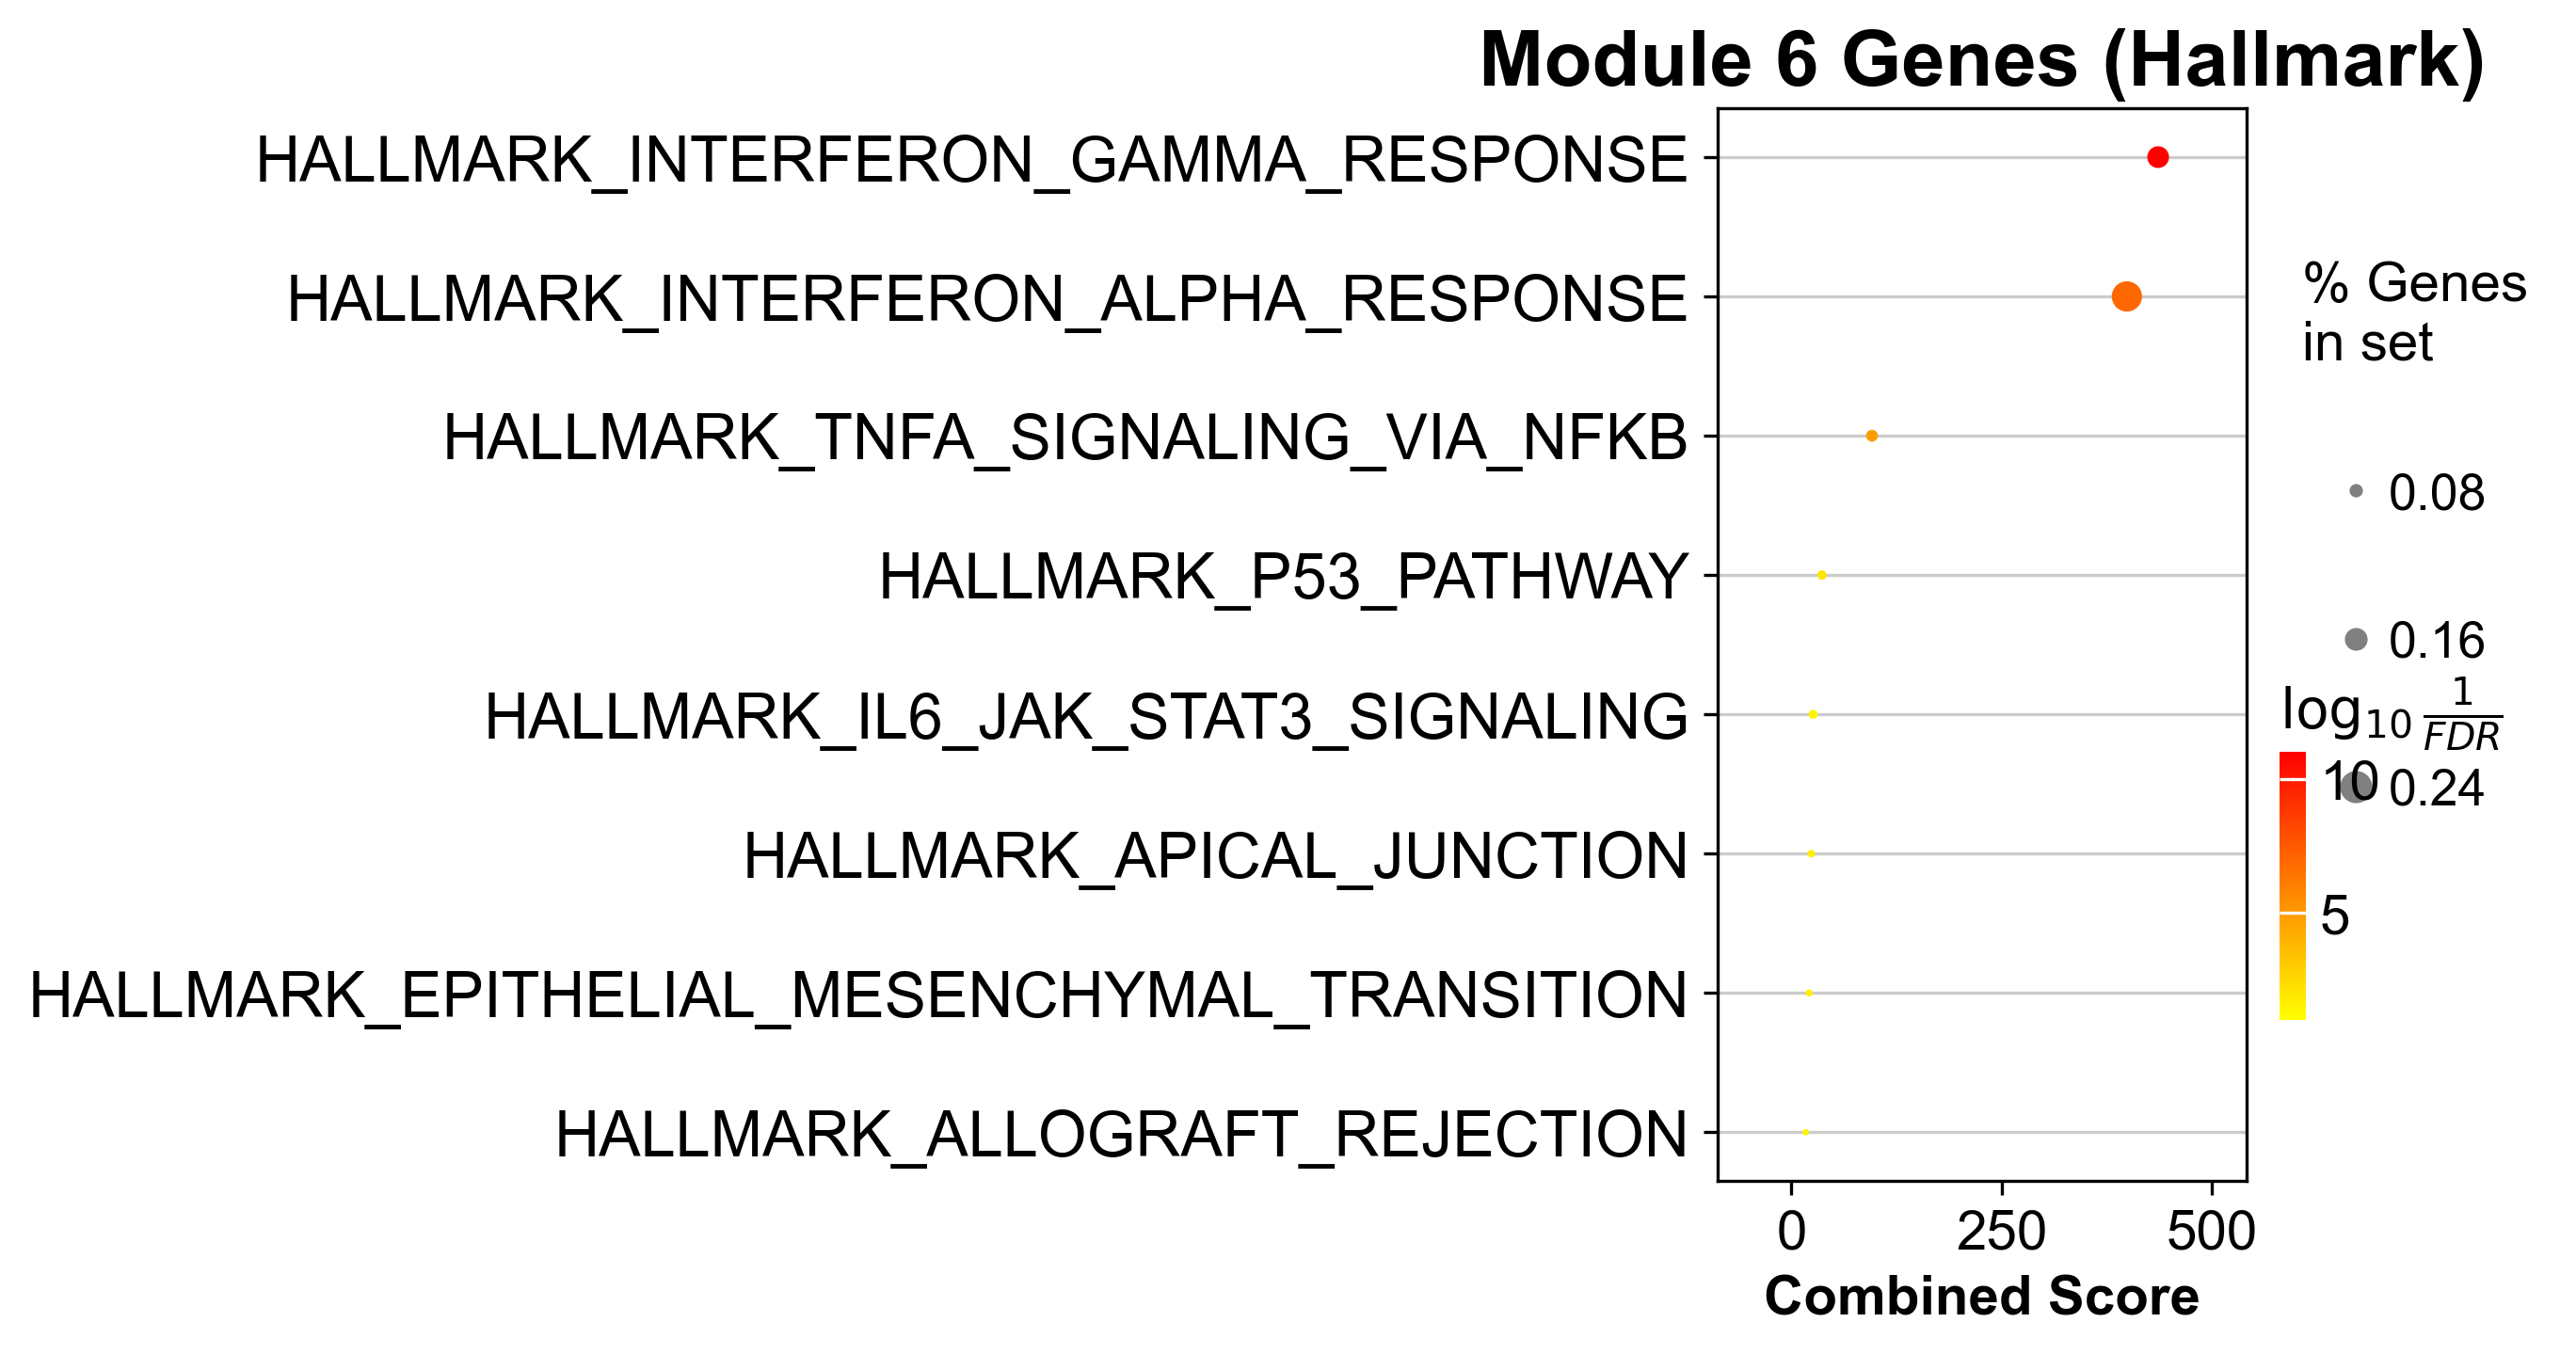

In [17]:
enr_mod6 = gp.enrichr(mod6, gene_sets=gmt, background=adata.var_names, outdir=None)
gp.dotplot(enr_mod6.res2d, figsize=(3, 5), title='Module 6 Genes (Hallmark)', cmap=plt.cm.autumn_r)
plt.show()

/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
/Users/cdpolt/miniforge3/envs/scanpy_gladstein/lib/python3.9/site-packages/gseapy/plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


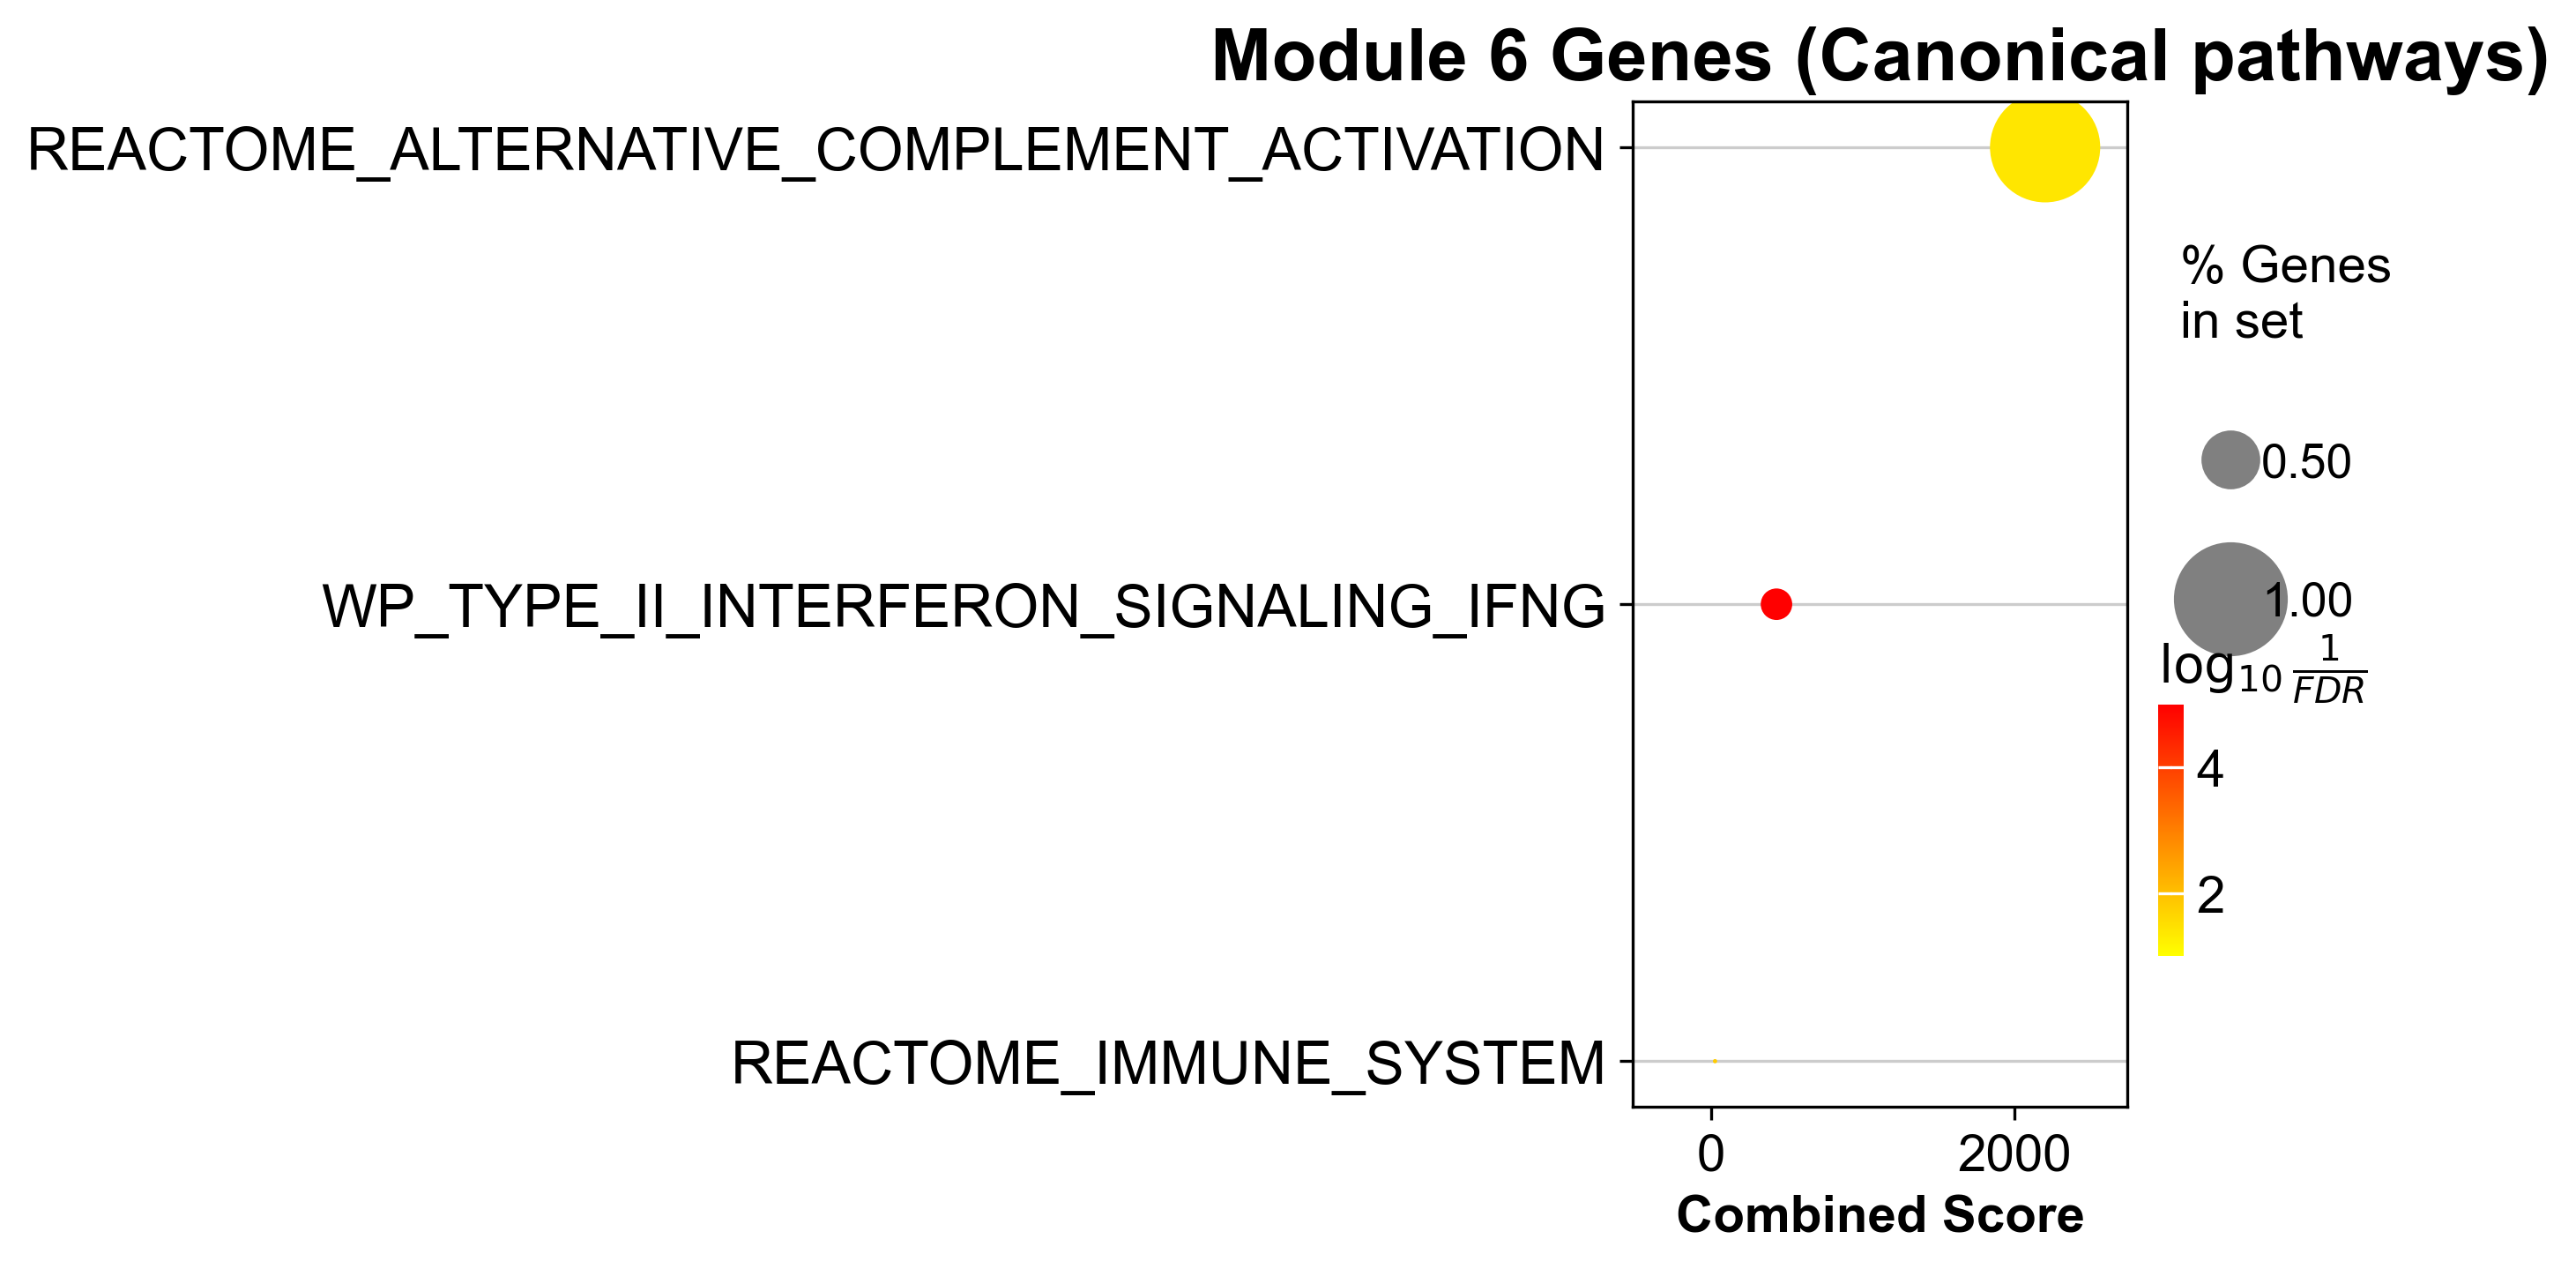

In [18]:
enr_mod6_2 = gp.enrichr(mod6, gene_sets=gmt2, background=adata.var_names, outdir=None)
gp.dotplot(enr_mod6_2.res2d, figsize=(3, 5), title='Module 6 Genes (Canonical pathways)', cmap=plt.cm.autumn_r)
plt.show()

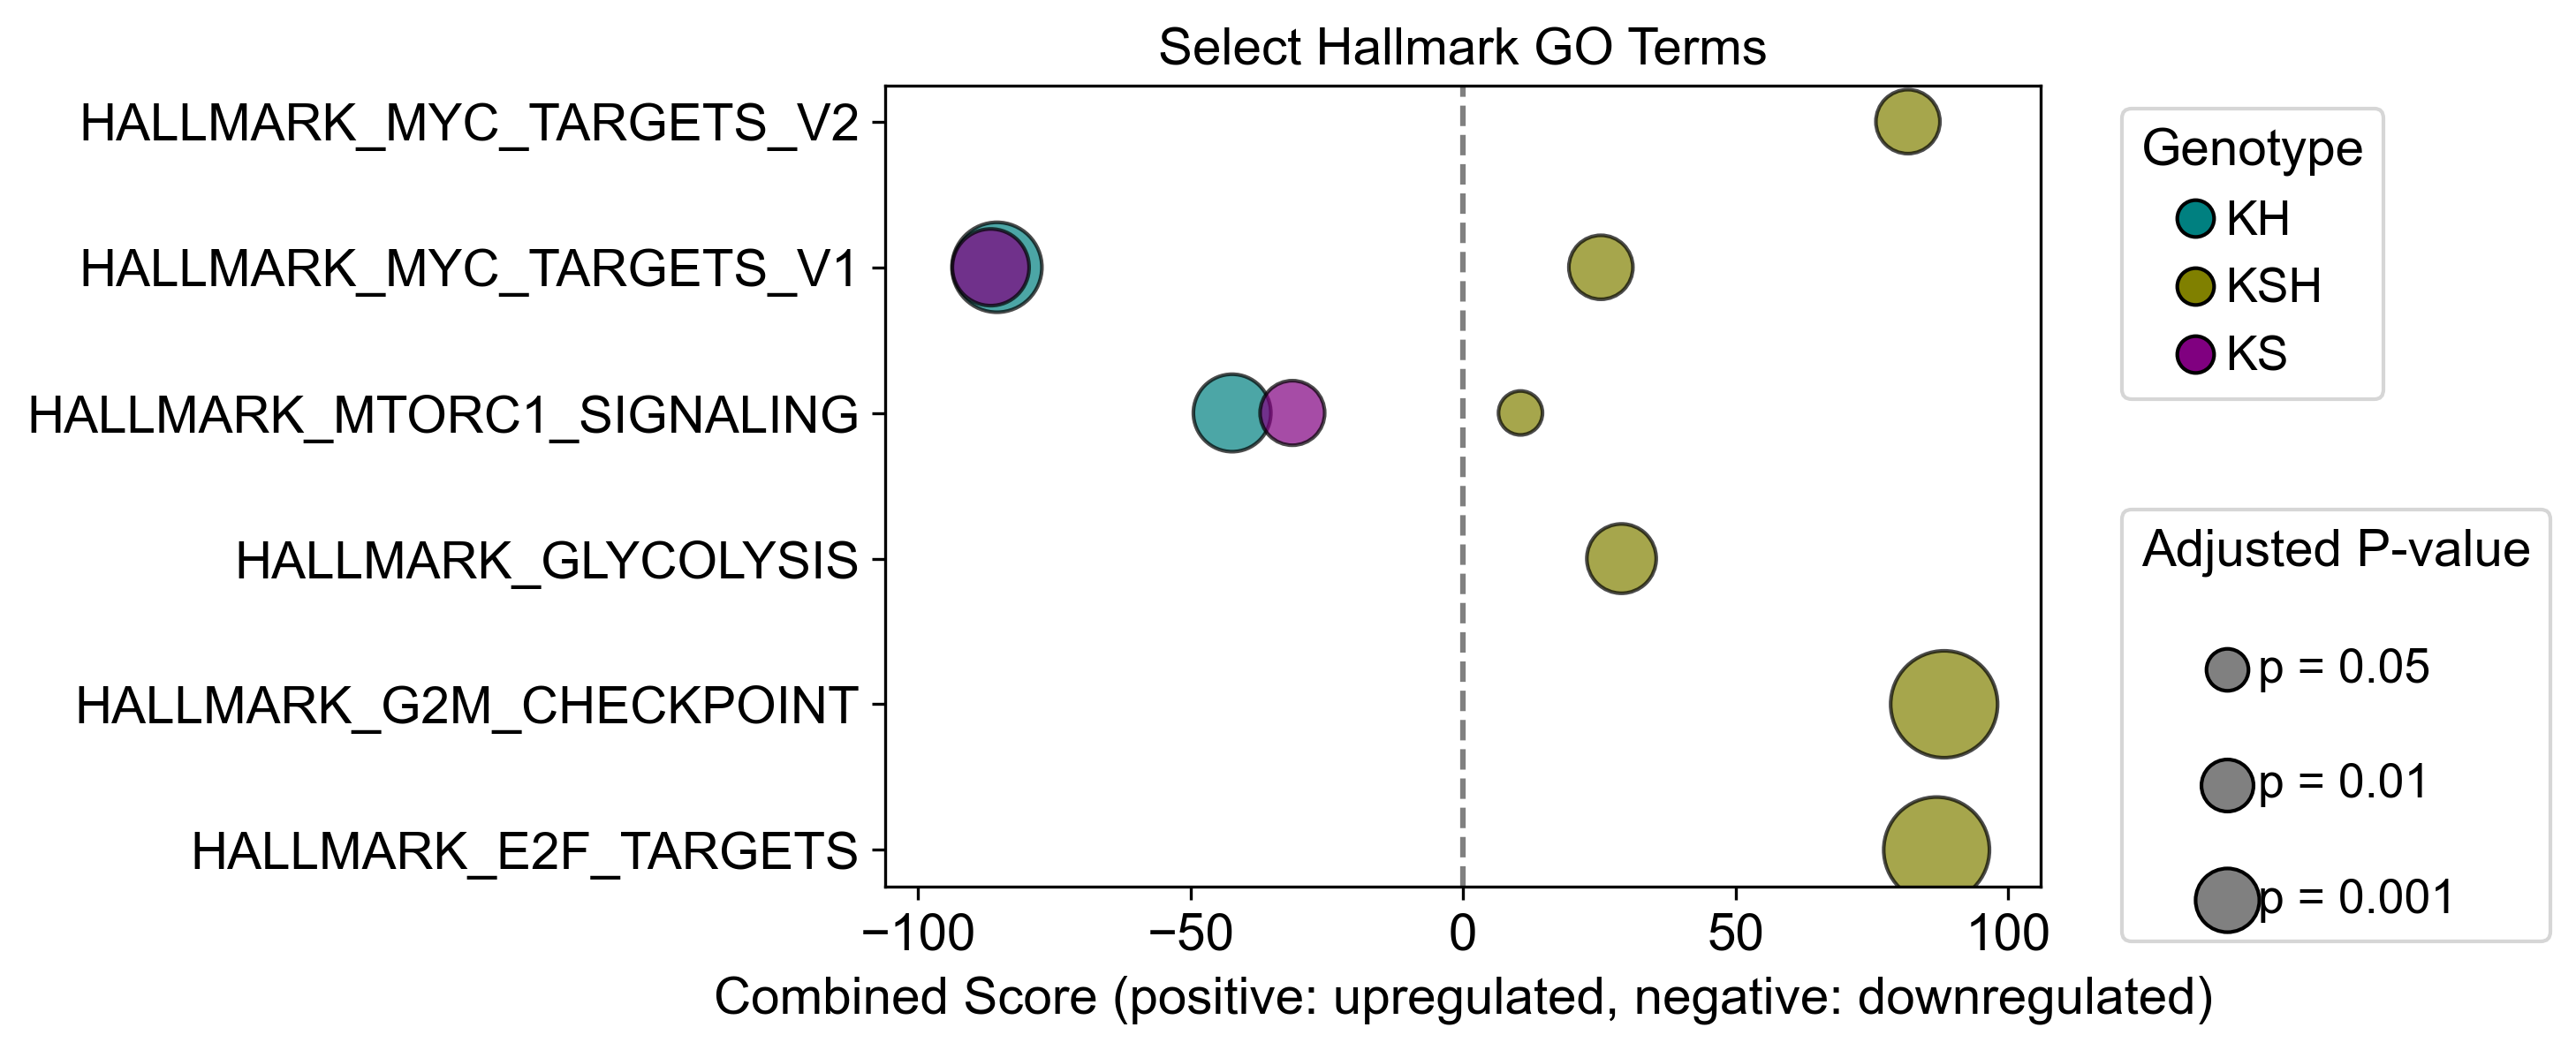

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df_upkh = enr_upkh.res2d.copy()
df_upkh['Direction'] = 'up'
df_upkh['Genotype'] = 'KH'

df_dwkh = enr_dwkh.res2d.copy()
df_dwkh['Direction'] = 'down'
df_dwkh['Genotype'] = 'KH'

df_upksh = enr_upksh.res2d.copy()
df_upksh['Direction'] = 'up'
df_upksh['Genotype'] = 'KSH'

df_dwksh = enr_dwksh.res2d.copy()
df_dwksh['Direction'] = 'down'
df_dwksh['Genotype'] = 'KSH'

df_upks = enr_upks.res2d.copy()
df_upks['Direction'] = 'up'
df_upks['Genotype'] = 'KS'

df_dwks = enr_dwks.res2d.copy()
df_dwks['Direction'] = 'down'
df_dwks['Genotype'] = 'KS'

df_upkh = df_upkh[df_upkh['Adjusted P-value'] < 0.05]
df_dwkh = df_dwkh[df_dwkh['Adjusted P-value'] < 0.05]
df_upksh = df_upksh[df_upksh['Adjusted P-value'] < 0.05]
df_dwksh = df_dwksh[df_dwksh['Adjusted P-value'] < 0.05]
df_upks = df_upks[df_upks['Adjusted P-value'] < 0.05]
df_dwks = df_dwks[df_dwks['Adjusted P-value'] < 0.05]

df_all = pd.concat([df_upkh, df_dwkh, df_upksh, df_dwksh, df_upks, df_dwks], ignore_index=True)

df_all['plot_score'] = df_all.apply(
    lambda row: np.abs(row['Combined Score']) if row['Direction'] == 'up'
                else -np.abs(row['Combined Score']),
    axis=1
)

scale_factor = 100
df_all['dot_size'] = -np.log10(df_all['Adjusted P-value']) * scale_factor

terms_to_keep = [
    "HALLMARK_GLYCOLYSIS",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_MYC_TARGETS_V1",
    "HALLMARK_MYC_TARGETS_V2",
    "HALLMARK_MTORC1_SIGNALING",
]
df_subset = df_all[df_all['Term'].isin(terms_to_keep)].copy()

go_terms = sorted(df_subset['Term'].unique())
term_to_y = {term: i for i, term in enumerate(go_terms)}
df_subset['y_pos'] = df_subset['Term'].map(term_to_y)

plt.figure(figsize=(10, len(go_terms) * 0.7))

genotype_colors = {'KH': 'teal', 'KSH': 'olive', 'KS': 'purple'}

for genotype, color in genotype_colors.items():
    subset = df_subset[df_subset['Genotype'] == genotype]
    plt.scatter(subset['plot_score'], subset['y_pos'],
                s=subset['dot_size'], color=color,
                alpha=0.7, edgecolors='k', label=genotype)

plt.axvline(0, color='gray', linestyle='--')

max_val = np.ceil(np.abs(df_subset['plot_score']).max() * 1.2)
plt.xlim(-max_val, max_val)

plt.yticks(range(len(go_terms)), go_terms)
plt.xlabel('Combined Score (positive: upregulated, negative: downregulated)')
plt.ylabel('')
plt.title('Select Hallmark GO Terms')

genotype_handles = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color, markersize=10,
                           markeredgecolor='k', label=genotype)
                    for genotype, color in genotype_colors.items()]

example_pvals = [0.05, 0.01, 0.001]
size_handles = [plt.scatter([], [], s=-np.log10(p) * scale_factor,
                            color='gray', edgecolors='k')
                for p in example_pvals]
size_labels = [f'p = {p}' for p in example_pvals]

legend1 = plt.legend(handles=genotype_handles, title='Genotype',
                     bbox_to_anchor=(1.05, 1), loc='upper left')
legend2 = plt.legend(size_handles, size_labels, scatterpoints=1,
                     title='Adjusted P-value', bbox_to_anchor=(1.05, 0.5),
                     loc='upper left', labelspacing=1.5)
plt.gca().add_artist(legend1)

plt.subplots_adjust(right=0.75)
plt.tight_layout()

plt.savefig(os.path.join(outdir, "ed4a.svg"), format='svg')

plt.show()
